The notebook is a preliminary implemention of an end to end fall detection pipeline that spans data ingestion, feature engineering, model training, cross validation, and cross domain evaluation for both a public wrist dataset (HIFD) and a proprietary Haelo. It provides the Stage 1 wrist baseline, Stage 2 wrist - ring calibration using non paired data, and a preliminary Stage 3 ring validation based on the existing Haelo dataset, with some limitations especially around the behaviour of the subject_23 subset (late 50% of the Haelo Dataset).

In [38]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

import warnings
warnings.filterwarnings("ignore")


hifd = pd.read_csv("all_subjects_windows_all_feats_bpm_6s_90pct_clean.csv")
hifd

,w,x,y,z,droll,dpitch,dyaw,ax,ay,az,heart,t_rel,win_id,sample_in_win,subject,file,class,label,bpm
0,0.4059,-0.2604,0.0021,-0.8760,-0.6,0.1,1.1,0.004,0.002,0.000,1023.0,3.06,0,0,subject_01,fall3.mat,fall,1,107.142857
1,0.4057,-0.2605,0.0021,-0.8760,-0.6,0.0,0.7,0.003,-0.001,0.001,1023.0,3.08,0,1,subject_01,fall3.mat,fall,1,107.142857
2,0.4057,-0.2605,0.0020,-0.8760,-0.6,-0.1,0.9,0.004,0.000,0.000,1023.0,3.10,0,2,subject_01,fall3.mat,fall,1,107.142857
3,0.4056,-0.2605,0.0020,-0.8760,-0.5,-0.2,0.9,0.008,0.002,-0.003,1023.0,3.12,0,3,subject_01,fall3.mat,fall,1,107.142857
4,0.4059,-0.2604,0.0022,-0.8760,-0.6,0.0,0.8,0.007,0.000,0.000,1023.0,3.14,0,4,subject_01,fall3.mat,fall,1,107.142857
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
590095,0.2060,0.2134,-0.5548,0.7772,-0.5,-0.1,0.0,0.004,0.006,-0.004,0.0,26.90,5904,95,subject_21,clap.mat,non-fall,0,130.434783
590096,0.2060,0.2134,-0.5548,0.7772,0.0,0.0,0.0,0.005,0.005,0.000,0.0,26.92,5904,96,subject_21,clap.mat,non-fall,0,130.434783
590097,0.2060,0.2134,-0.5548,0.7772,0.0,0.0,0.0,0.006,0.004,-0.002,0.0,26.94,5904,97,subject_21,clap.mat,non-fall,0,130.434783
590098,0.2060,0.2134,-0.5548,0.7772,0.0,0.0,0.0,0.005,0.006,-0.004,0.0,26.96,5904,98,subject_21,clap.mat,non-fall,0,130.434783


**Adding Magnitude to both Acc and Gyro**

In [39]:
hifd = pd.read_csv("all_subjects_windows_all_feats_bpm_6s_90pct_clean_with_mag.csv")

features = [
    "ax", "ay", "az", "acc_mag",
    "droll", "dpitch", "dyaw", "gyr_mag",
    "bpm"
]

def summarize(group):
    return group[features].describe(percentiles=[0.05, 0.5, 0.95]).T

summary_non = summarize(hifd[hifd["label"] == 0])
summary_fall = summarize(hifd[hifd["label"] == 1])

In [40]:
hifd

,w,x,y,z,droll,dpitch,dyaw,ax,ay,az,...,t_rel,win_id,sample_in_win,subject,file,class,label,bpm,acc_mag,gyr_mag
0,0.4059,-0.2604,0.0021,-0.8760,-0.6,0.1,1.1,0.004,0.002,0.000,...,3.06,0,0,subject_01,fall3.mat,fall,1,107.142857,0.004472,1.256981
1,0.4057,-0.2605,0.0021,-0.8760,-0.6,0.0,0.7,0.003,-0.001,0.001,...,3.08,0,1,subject_01,fall3.mat,fall,1,107.142857,0.003317,0.921954
2,0.4057,-0.2605,0.0020,-0.8760,-0.6,-0.1,0.9,0.004,0.000,0.000,...,3.10,0,2,subject_01,fall3.mat,fall,1,107.142857,0.004000,1.086278
3,0.4056,-0.2605,0.0020,-0.8760,-0.5,-0.2,0.9,0.008,0.002,-0.003,...,3.12,0,3,subject_01,fall3.mat,fall,1,107.142857,0.008775,1.048809
4,0.4059,-0.2604,0.0022,-0.8760,-0.6,0.0,0.8,0.007,0.000,0.000,...,3.14,0,4,subject_01,fall3.mat,fall,1,107.142857,0.007000,1.000000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
590095,0.2060,0.2134,-0.5548,0.7772,-0.5,-0.1,0.0,0.004,0.006,-0.004,...,26.90,5904,95,subject_21,clap.mat,non-fall,0,130.434783,0.008246,0.509902
590096,0.2060,0.2134,-0.5548,0.7772,0.0,0.0,0.0,0.005,0.005,0.000,...,26.92,5904,96,subject_21,clap.mat,non-fall,0,130.434783,0.007071,0.000000
590097,0.2060,0.2134,-0.5548,0.7772,0.0,0.0,0.0,0.006,0.004,-0.002,...,26.94,5904,97,subject_21,clap.mat,non-fall,0,130.434783,0.007483,0.000000
590098,0.2060,0.2134,-0.5548,0.7772,0.0,0.0,0.0,0.005,0.006,-0.004,...,26.96,5904,98,subject_21,clap.mat,non-fall,0,130.434783,0.008775,0.000000


**We need to get HIFD parameters to help put Haelo in the same space**

In [41]:
feat_cols = [
    "ax", "ay", "az",              # linear acceleration (g)
    "droll", "dpitch", "dyaw",     # angular velocity
    "bpm",                         # heart/HR feature name
    "acc_mag", "gyr_mag"           # magnitudes
]

hifd_train = hifd

mu = hifd_train[feat_cols].mean()
sigma = hifd_train[feat_cols].std()

mu.to_csv("hifd_feature_mean.csv")
sigma.to_csv("hifd_feature_std.csv")

In [42]:
hifd

,w,x,y,z,droll,dpitch,dyaw,ax,ay,az,...,t_rel,win_id,sample_in_win,subject,file,class,label,bpm,acc_mag,gyr_mag
0,0.4059,-0.2604,0.0021,-0.8760,-0.6,0.1,1.1,0.004,0.002,0.000,...,3.06,0,0,subject_01,fall3.mat,fall,1,107.142857,0.004472,1.256981
1,0.4057,-0.2605,0.0021,-0.8760,-0.6,0.0,0.7,0.003,-0.001,0.001,...,3.08,0,1,subject_01,fall3.mat,fall,1,107.142857,0.003317,0.921954
2,0.4057,-0.2605,0.0020,-0.8760,-0.6,-0.1,0.9,0.004,0.000,0.000,...,3.10,0,2,subject_01,fall3.mat,fall,1,107.142857,0.004000,1.086278
3,0.4056,-0.2605,0.0020,-0.8760,-0.5,-0.2,0.9,0.008,0.002,-0.003,...,3.12,0,3,subject_01,fall3.mat,fall,1,107.142857,0.008775,1.048809
4,0.4059,-0.2604,0.0022,-0.8760,-0.6,0.0,0.8,0.007,0.000,0.000,...,3.14,0,4,subject_01,fall3.mat,fall,1,107.142857,0.007000,1.000000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
590095,0.2060,0.2134,-0.5548,0.7772,-0.5,-0.1,0.0,0.004,0.006,-0.004,...,26.90,5904,95,subject_21,clap.mat,non-fall,0,130.434783,0.008246,0.509902
590096,0.2060,0.2134,-0.5548,0.7772,0.0,0.0,0.0,0.005,0.005,0.000,...,26.92,5904,96,subject_21,clap.mat,non-fall,0,130.434783,0.007071,0.000000
590097,0.2060,0.2134,-0.5548,0.7772,0.0,0.0,0.0,0.006,0.004,-0.002,...,26.94,5904,97,subject_21,clap.mat,non-fall,0,130.434783,0.007483,0.000000
590098,0.2060,0.2134,-0.5548,0.7772,0.0,0.0,0.0,0.005,0.006,-0.004,...,26.96,5904,98,subject_21,clap.mat,non-fall,0,130.434783,0.008775,0.000000


**Import Haelo and map to the same features as HIFD**

In [43]:
g_const = 9.81

falls = pd.read_csv("data_fall.csv")
non_falls = pd.read_csv("data.csv")
haelo = pd.concat([non_falls, falls], ignore_index=True)

haelo["ax"] = haelo["accX_m/s2"] / g_const
haelo["ay"] = haelo["accY_m/s2"] / g_const
haelo["az"] = haelo["accZ_m/s2"] / g_const

haelo["droll"] = haelo["gyrX_dps"]
haelo["dpitch"] = haelo["gyrY_dps"]
haelo["dyaw"] = haelo["gyrZ_dps"]

haelo["bpm"] = haelo["heartRate_bpm"]

haelo["acc_mag"] = np.sqrt(haelo["ax"]**2 + haelo["ay"]**2 + haelo["az"]**2)
haelo["gyr_mag"] = np.sqrt(
    haelo["droll"]**2 + haelo["dpitch"]**2 + haelo["dyaw"]**2
)


In [44]:
haelo

,timestamp_ms,accX_m/s2,accY_m/s2,accZ_m/s2,gyrX_dps,gyrY_dps,gyrZ_dps,heartRate_bpm,isHeartRateActual,ax,ay,az,droll,dpitch,dyaw,bpm,acc_mag,gyr_mag
0,1.767490e+12,-3.174808,2.528952,-8.940221,-0.056460,-0.030893,-0.020240,76.0,1.0,-0.323630,0.257793,-0.911338,-0.056460,-0.030893,-0.020240,76.0,1.000864,0.067467
1,1.767490e+12,-3.241249,2.549304,-8.925856,-0.080962,-0.024501,-0.029828,76.0,1.0,-0.330403,0.259868,-0.909873,-0.080962,-0.024501,-0.029828,76.0,1.002281,0.089693
2,1.767490e+12,-3.258607,2.571451,-8.919271,-0.089484,0.001065,-0.024501,76.0,1.0,-0.332172,0.262125,-0.909202,-0.089484,0.001065,-0.024501,76.0,1.002844,0.092784
3,1.767490e+12,-3.201145,2.619935,-8.934236,-0.080962,0.012783,-0.021305,76.0,0.0,-0.326314,0.267068,-0.910727,-0.080962,0.012783,-0.021305,76.0,1.003609,0.084689
4,1.767490e+12,-3.080234,2.725283,-8.961171,-0.079897,0.015979,-0.025567,76.0,0.0,-0.313989,0.277807,-0.913473,-0.079897,0.015979,-0.025567,76.0,1.005086,0.085396
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1139995,1.767570e+12,2.518178,6.020403,-7.302537,-0.003195,-0.003195,0.000000,75.0,0.0,0.256695,0.613701,-0.744397,-0.003195,-0.003195,0.000000,75.0,0.998323,0.004518
1139996,1.767570e+12,2.531945,6.030579,-7.310917,-0.006391,-0.001065,-0.002130,75.0,0.0,0.258098,0.614738,-0.745251,-0.006391,-0.001065,-0.002130,75.0,0.999959,0.006820
1139997,1.767570e+12,2.475081,6.062902,-7.283383,-0.007457,-0.007457,0.000000,75.0,0.0,0.252302,0.618033,-0.742445,-0.007457,-0.007457,0.000000,75.0,0.998421,0.010546
1139998,1.767570e+12,2.502615,6.041353,-7.302537,0.011718,0.000000,0.005326,75.0,1.0,0.255109,0.615836,-0.744397,0.011718,0.000000,0.005326,75.0,0.999231,0.012872


**EDA before standisation**

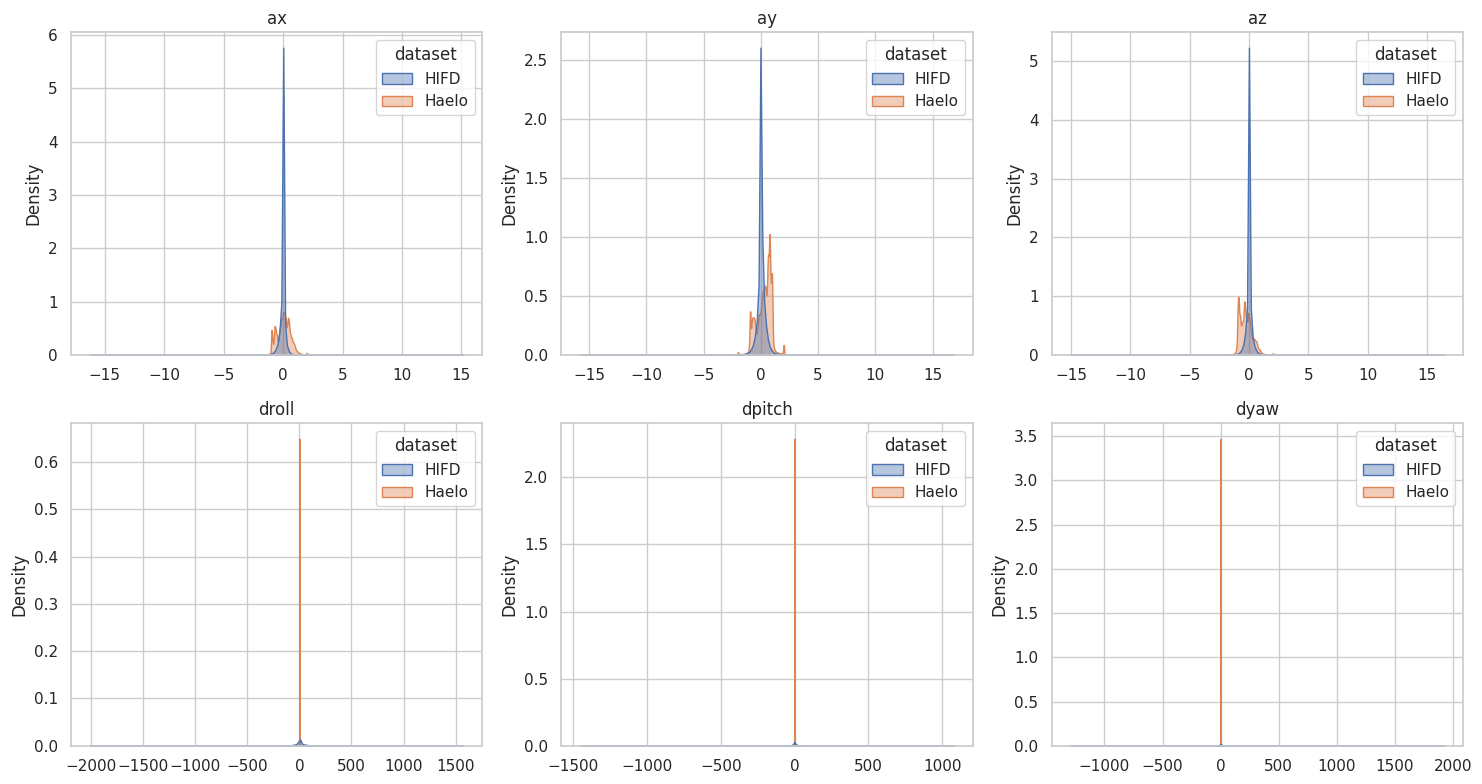

In [45]:
feat_cols = [
    "ax", "ay", "az",
    "droll", "dpitch", "dyaw",
    "bpm",
    "acc_mag", "gyr_mag",
]

X_hifd_EDA = hifd[feat_cols].copy()
X_haelo_EDA = haelo[feat_cols].copy()


def compare_feature_distributions(X_hifd_EDA, X_haelo_EDA, y_hifd=None, y_haelo=None,
                                  n_features_to_plot=6):
    df_h = X_hifd_EDA.copy()
    df_h["dataset"] = "HIFD"
    if y_hifd is not None:
        df_h["label"] = y_hifd

    df_ha = X_haelo_EDA.copy()
    df_ha["dataset"] = "Haelo"
    if y_haelo is not None:
        df_ha["label"] = y_haelo

    df_all = pd.concat([df_h, df_ha], ignore_index=True)

    feature_cols = [c for c in X_hifd_EDA.columns][:n_features_to_plot]

    sns.set(style="whitegrid")
    n_cols = 3
    n_rows = int(np.ceil(len(feature_cols) / n_cols))
    plt.figure(figsize=(5 * n_cols, 4 * n_rows))

    for i, col in enumerate(feature_cols, start=1):
        plt.subplot(n_rows, n_cols, i)
        sns.kdeplot(
            data=df_all,
            x=col,
            hue="dataset",
            common_norm=False,
            fill=True,
            alpha=0.4,
        )
        plt.title(col)
        plt.xlabel("")
    plt.tight_layout()
    plt.show()

compare_feature_distributions(X_hifd_EDA, X_haelo_EDA)

**Standardise Haelo using HIFD parameters**

In [46]:
import pandas as pd
import numpy as np

mu_df = pd.read_csv("hifd_feature_mean.csv", index_col=0)
sigma_df = pd.read_csv("hifd_feature_std.csv", index_col=0)
mu = mu_df.iloc[:, 0]
sigma = sigma_df.iloc[:, 0]

feat_cols = [
    "ax", "ay", "az",
    "droll", "dpitch", "dyaw",
    "bpm",
    "acc_mag", "gyr_mag",
]

X_hifd = hifd[feat_cols].copy()
X_hifd_z = (X_hifd - mu[feat_cols]) / sigma[feat_cols]

X_haelo = haelo[feat_cols].copy()
X_haelo_z = (X_haelo - mu[feat_cols]) / sigma[feat_cols]


In [47]:
X_hifd_z

,ax,ay,az,droll,dpitch,dyaw,bpm,acc_mag,gyr_mag
0,0.176667,-0.011605,0.058905,-0.015663,-0.003105,0.000786,-0.310536,-0.622162,-0.896329
1,0.173679,-0.018735,0.061780,-0.015663,-0.004902,-0.003941,-0.310536,-0.624286,-0.899706
2,0.176667,-0.016358,0.058905,-0.015663,-0.006698,-0.001577,-0.310536,-0.623030,-0.898050
3,0.188619,-0.011605,0.050279,-0.014524,-0.008495,-0.001577,-0.310536,-0.614252,-0.898428
4,0.185631,-0.016358,0.058905,-0.015663,-0.004902,-0.002759,-0.310536,-0.617515,-0.898920
...,...,...,...,...,...,...,...,...,...
590095,0.176667,-0.002099,0.047403,-0.014524,-0.006698,-0.012212,0.477038,-0.615224,-0.903860
590096,0.179655,-0.004475,0.058905,-0.008830,-0.004902,-0.012212,0.477038,-0.617384,-0.909000
590097,0.182643,-0.006852,0.053154,-0.008830,-0.004902,-0.012212,0.477038,-0.616626,-0.909000
590098,0.179655,-0.002099,0.047403,-0.008830,-0.004902,-0.012212,0.477038,-0.614252,-0.909000


In [48]:
X_haelo_z

,ax,ay,az,droll,dpitch,dyaw,bpm,acc_mag,gyr_mag
0,-0.802256,0.596300,-2.561535,-0.009473,-0.005457,-0.012451,-1.363575,1.209466,-0.908320
1,-0.822492,0.601230,-2.557325,-0.009752,-0.005342,-0.012564,-1.363575,1.212069,-0.908096
2,-0.827779,0.606596,-2.555395,-0.009849,-0.004883,-0.012502,-1.363575,1.213105,-0.908065
3,-0.810277,0.618341,-2.559781,-0.009752,-0.004672,-0.012464,-1.363575,1.214511,-0.908146
4,-0.773451,0.643863,-2.567676,-0.009740,-0.004615,-0.012514,-1.363575,1.217227,-0.908139
...,...,...,...,...,...,...,...,...,...
1139995,0.931693,1.442131,-2.081519,-0.008867,-0.004959,-0.012212,-1.397388,1.204793,-0.908954
1139996,0.935886,1.444596,-2.083975,-0.008903,-0.004921,-0.012237,-1.397388,1.207801,-0.908931
1139997,0.918566,1.452427,-2.075905,-0.008915,-0.005036,-0.012212,-1.397388,1.204975,-0.908894
1139998,0.926953,1.447206,-2.081519,-0.008697,-0.004902,-0.012149,-1.397388,1.206462,-0.908870


**Do EDA Here**

In [49]:
def compare_feature_distributions(X_hifd_z, X_haelo_z, y_hifd=None, y_haelo=None,
                                  n_features_to_plot=6):
    df_h = X_hifd_z.copy()
    df_h["dataset"] = "HIFD"
    if y_hifd is not None:
        df_h["label"] = y_hifd

    df_ha = X_haelo_z.copy()
    df_ha["dataset"] = "Haelo"
    if y_haelo is not None:
        df_ha["label"] = y_haelo

    df_all = pd.concat([df_h, df_ha], ignore_index=True)

    feature_cols = [c for c in X_hifd_z.columns][:n_features_to_plot]

    sns.set(style="whitegrid")
    n_cols = 3
    n_rows = int(np.ceil(len(feature_cols) / n_cols))
    plt.figure(figsize=(5 * n_cols, 4 * n_rows))

    for i, col in enumerate(feature_cols, start=1):
        plt.subplot(n_rows, n_cols, i)
        sns.kdeplot(
            data=df_all,
            x=col,
            hue="dataset",
            common_norm=False,
            fill=True,
            alpha=0.4,
        )
        plt.title(col)
        plt.xlabel("")
    plt.tight_layout()
    plt.show()


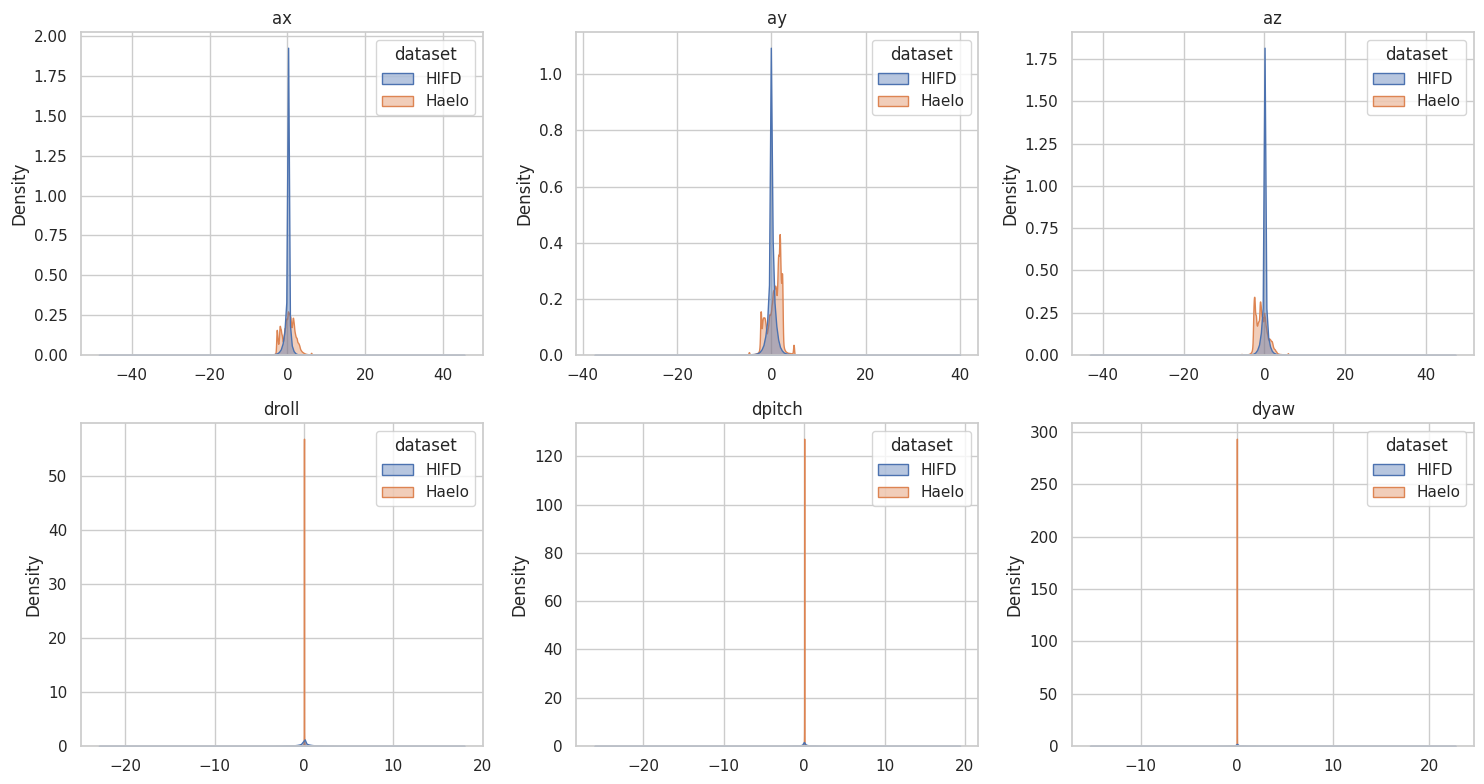

In [50]:
compare_feature_distributions(X_hifd_z, X_haelo_z)

In [51]:
def iqr(x):
    x = np.asarray(x)
    if x.size == 0:
        return 0.0
    return np.percentile(x, 75) - np.percentile(x, 25)
def zcr(x):
    x = np.asarray(x)
    if x.size < 2:
        return 0.0
    return np.mean(np.diff(np.sign(x)) != 0)
def entropy_approx(x, bins=20):
    x = np.asarray(x)
    if x.size == 0:
        return 0.0
    hist, _ = np.histogram(x, bins=bins, density=True)
    hist = hist[hist > 0]
    if len(hist) == 0:
        return 0.0
    return -np.sum(hist * np.log(hist))
def slope(x):
    x = np.asarray(x)
    if x.size < 2:
        return 0.0
    t = np.arange(len(x), dtype=float)
    # normalise safely
    t_std = t.std()
    x_std = x.std()
    if t_std == 0 or x_std == 0:
        return 0.0
    t = (t - t.mean()) / (t_std + 1e-8)
    x_ = (x - x.mean()) / (x_std + 1e-8)
    try:
        return np.polyfit(t, x_, 1)[0]
    except Exception:
        return 0.0
def area(x):
    x = np.asarray(x)
    if x.size == 0:
        return 0.0
    return np.sum(np.abs(x))

def safe_kurtosis(x):
    s = pd.Series(x)
    if len(s) < 3 or s.std() == 0:
        return 0.0
    v = s.kurt()
    return 0.0 if pd.isna(v) or np.isinf(v) else float(v)
def safe_skew(x):
    s = pd.Series(x)
    if len(s) < 2 or s.std() == 0:
        return 0.0
    v = s.skew()
    return 0.0 if pd.isna(v) or np.isinf(v) else float(v)
def extract_window_features_6s_90pct(
    df,
    fs=50,
    win_sec=6.0,
    overlap=0.05,  # 5% overlap
    acc_thresh_z=3.0,
):
    """
    df: DataFrame with columns:
        ['subject','label','ax','ay','az','droll','dpitch','dyaw','bpm','acc_mag','gyr_mag']
        sorted by time within each subject.
    """
    win_len = int(win_sec * fs)
    step = int(win_len * (1.0 - overlap))

    feat_rows = []
    win_counter = 0
    for subj, g_subj in df.groupby("subject"):
        g_subj = g_subj.reset_index(drop=True)
        n = len(g_subj)

        start = 0
        while start + win_len <= n:
            end = start + win_len
            w = g_subj.iloc[start:end]

            win_id = f"{subj}_win_{win_counter}"
            win_counter += 1

            labels = w["label"].values
            label_win = 1 if np.any(labels == 1) else 0

            feats = {
                "subject": subj,
                "label": label_win,
                "win_id": win_id,
            }

            acc_mag = w["acc_mag"].to_numpy()
            gyr_mag = w["gyr_mag"].to_numpy()

            bpm_raw = w["bpm"].to_numpy()
            bpm = bpm_raw[np.isfinite(bpm_raw)]
            feats["acc_energy"] = np.sum(acc_mag ** 2) if acc_mag.size > 0 else 0.0
            feats["acc_max"] = float(np.max(acc_mag)) if acc_mag.size > 0 else 0.0
            feats["acc_min"] = float(np.min(acc_mag)) if acc_mag.size > 0 else 0.0
            feats["gyr_energy"] = np.sum(gyr_mag ** 2) if gyr_mag.size > 0 else 0.0
            feats["gyr_max"] = float(np.max(gyr_mag)) if gyr_mag.size > 0 else 0.0
            feats["gyr_min"] = float(np.min(gyr_mag)) if gyr_mag.size > 0 else 0.0

            if bpm.size > 0:
                feats["bpm_mean"] = float(bpm.mean())
                feats["bpm_std"] = float(bpm.std())
                feats["bpm_min"] = float(bpm.min())
                feats["bpm_max"] = float(bpm.max())
                feats["bpm_iqr"] = float(iqr(bpm))
                feats["bpm_kurtosis"] = safe_kurtosis(bpm)
                feats["bpm_skew"] = safe_skew(bpm)
            else:
                feats["bpm_mean"] = 0.0
                feats["bpm_std"] = 0.0
                feats["bpm_min"] = 0.0
                feats["bpm_max"] = 0.0
                feats["bpm_iqr"] = 0.0
                feats["bpm_kurtosis"] = 0.0
                feats["bpm_skew"] = 0.0

            for col in ["ax", "ay", "az"]:
                x_raw = w[col].to_numpy()
                x = x_raw[np.isfinite(x_raw)]
                if x.size == 0:
                    feats[f"{col}_mean"] = 0.0
                    feats[f"{col}_std"] = 0.0
                    feats[f"{col}_min"] = 0.0
                    feats[f"{col}_max"] = 0.0
                    feats[f"{col}_iqr"] = 0.0
                    feats[f"{col}_kurtosis"] = 0.0
                    feats[f"{col}_skew"] = 0.0
                else:
                    feats[f"{col}_mean"] = float(x.mean())
                    feats[f"{col}_std"] = float(x.std())
                    feats[f"{col}_min"] = float(x.min())
                    feats[f"{col}_max"] = float(x.max())
                    feats[f"{col}_iqr"] = float(iqr(x))
                    feats[f"{col}_kurtosis"] = safe_kurtosis(x)
                    feats[f"{col}_skew"] = safe_skew(x)

            for col in ["droll", "dpitch", "dyaw"]:
                x_raw = w[col].to_numpy()
                x = x_raw[np.isfinite(x_raw)]
                if x.size == 0:
                    feats[f"{col}_mean"] = 0.0
                    feats[f"{col}_std"] = 0.0
                    feats[f"{col}_min"] = 0.0
                    feats[f"{col}_max"] = 0.0
                    feats[f"{col}_iqr"] = 0.0
                    feats[f"{col}_kurtosis"] = 0.0
                    feats[f"{col}_skew"] = 0.0
                else:
                    feats[f"{col}_mean"] = float(x.mean())
                    feats[f"{col}_std"] = float(x.std())
                    feats[f"{col}_min"] = float(x.min())
                    feats[f"{col}_max"] = float(x.max())
                    feats[f"{col}_iqr"] = float(iqr(x))
                    feats[f"{col}_kurtosis"] = safe_kurtosis(x)
                    feats[f"{col}_skew"] = safe_skew(x)

            feats["acc_mag_iqr"] = float(iqr(acc_mag)) if acc_mag.size > 0 else 0.0
            feats["acc_mag_zcr"] = float(zcr(acc_mag)) if acc_mag.size > 0 else 0.0
            feats["acc_mag_slope"] = float(slope(acc_mag)) if acc_mag.size > 0 else 0.0
            feats["acc_mag_area"] = float(area(acc_mag)) if acc_mag.size > 0 else 0.0
            feats["gyr_mag_iqr"] = float(iqr(gyr_mag)) if gyr_mag.size > 0 else 0.0
            feats["gyr_mag_area"] = float(area(gyr_mag)) if gyr_mag.size > 0 else 0.0

            feat_rows.append(feats)
            start += step

    feat_df = pd.DataFrame(feat_rows)
    return feat_df

**Add Subjects and Labels to the HIFD and HAELO from above**

In [52]:
import pandas as pd
import numpy as np

hifd_path = "all_subjects_windows_all_feats_bpm_6s_90pct_clean.csv"
hifd = pd.read_csv(hifd_path)

acc_cols = ["ax", "ay", "az"]
gyr_cols = ["droll", "dpitch", "dyaw"]

if all(c in hifd.columns for c in acc_cols):
    hifd["acc_mag"] = np.sqrt(
        hifd["ax"]**2 + hifd["ay"]**2 + hifd["az"]**2
    )
if all(c in hifd.columns for c in gyr_cols):
    hifd["gyr_mag"] = np.sqrt(
        hifd["droll"]**2 + hifd["dpitch"]**2 + hifd["dyaw"]**2
    )

out_path = "all_subjects_windows_all_feats_bpm_6s_90pct_clean_with_mag.csv"
hifd.to_csv(out_path, index=False)
print("Saved with magnitudes to:", out_path)

hifd_feat = pd.concat(
    [hifd[["subject", "label"]].reset_index(drop=True),
     X_hifd_z.reset_index(drop=True)],
    axis=1
)

hifd_feat

Saved with magnitudes to: all_subjects_windows_all_feats_bpm_6s_90pct_clean_with_mag.csv


,subject,label,ax,ay,az,droll,dpitch,dyaw,bpm,acc_mag,gyr_mag
0,subject_01,1,0.176667,-0.011605,0.058905,-0.015663,-0.003105,0.000786,-0.310536,-0.622162,-0.896329
1,subject_01,1,0.173679,-0.018735,0.061780,-0.015663,-0.004902,-0.003941,-0.310536,-0.624286,-0.899706
2,subject_01,1,0.176667,-0.016358,0.058905,-0.015663,-0.006698,-0.001577,-0.310536,-0.623030,-0.898050
3,subject_01,1,0.188619,-0.011605,0.050279,-0.014524,-0.008495,-0.001577,-0.310536,-0.614252,-0.898428
4,subject_01,1,0.185631,-0.016358,0.058905,-0.015663,-0.004902,-0.002759,-0.310536,-0.617515,-0.898920
...,...,...,...,...,...,...,...,...,...,...,...
590095,subject_21,0,0.176667,-0.002099,0.047403,-0.014524,-0.006698,-0.012212,0.477038,-0.615224,-0.903860
590096,subject_21,0,0.179655,-0.004475,0.058905,-0.008830,-0.004902,-0.012212,0.477038,-0.617384,-0.909000
590097,subject_21,0,0.182643,-0.006852,0.053154,-0.008830,-0.004902,-0.012212,0.477038,-0.616626,-0.909000
590098,subject_21,0,0.179655,-0.002099,0.047403,-0.008830,-0.004902,-0.012212,0.477038,-0.614252,-0.909000


In [53]:
hifd_windows = extract_window_features_6s_90pct(hifd_feat, fs=50)
hifd_windows.to_csv("hifd_windows.csv")
hifd_windows

,subject,label,win_id,acc_energy,acc_max,acc_min,gyr_energy,gyr_max,gyr_min,bpm_mean,...,dyaw_max,dyaw_iqr,dyaw_kurtosis,dyaw_skew,acc_mag_iqr,acc_mag_zcr,acc_mag_slope,acc_mag_area,gyr_mag_iqr,gyr_mag_area
0,subject_01,1,subject_01_win_0,113.532175,-0.597090,-0.626706,241.624258,-0.891367,-0.902786,-0.218527,...,0.004331,0.002363,0.138066,0.298889,0.008316,0.000000,-0.026255,184.543830,0.003084,269.233842
1,subject_01,1,subject_01_win_1,6825.745192,43.368025,-0.626706,1651.639527,9.287565,-0.903036,-0.626189,...,8.887750,0.766871,5.510057,1.086321,1.636771,0.073579,0.067312,534.457476,1.957029,450.056902
2,subject_01,1,subject_01_win_2,109.927419,-0.589733,-0.618612,240.821617,-0.805231,-0.909000,0.472830,...,0.003149,0.002363,8.660936,-2.348620,0.005681,0.000000,0.076086,181.594431,0.001711,268.764931
3,subject_01,1,subject_01_win_3,1246.309487,9.368082,-0.615449,656.954825,8.680712,-0.900328,-0.322777,...,1.727133,0.336762,25.515578,-4.391278,0.878396,0.046823,0.192706,347.808967,1.314173,283.681898
4,subject_01,1,subject_01_win_4,101.810992,0.170696,-0.626706,225.910693,-0.483392,-0.903762,-0.728888,...,0.358817,0.002363,46.075912,5.569757,0.008107,0.006689,-0.327653,173.519946,0.009039,259.062707
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2055,subject_21,0,subject_21_win_2055,105.612421,1.979181,-0.626272,213.426539,0.722868,-0.909000,1.340626,...,1.682231,0.005908,7.153451,2.848762,0.016026,0.013378,-0.367545,170.992422,0.033035,246.578045
2056,subject_21,0,subject_21_win_2056,113.660630,-0.603617,-0.626272,247.353874,-0.884577,-0.909000,0.838880,...,0.005512,0.000000,33.460765,4.462233,0.004499,0.000000,-0.050198,184.653253,0.000000,272.406512
2057,subject_21,0,subject_21_win_2057,176.865037,7.676906,-0.626272,250.908859,2.203233,-0.909000,0.923795,...,1.564069,0.000000,4.444662,-0.274141,0.035481,0.020067,0.491984,183.787150,0.009128,260.639158
2058,subject_21,0,subject_21_win_2058,161.004918,7.676906,-0.621959,213.688020,2.203233,-0.909000,1.240491,...,1.574704,0.441040,1.104217,0.255261,0.301956,0.033445,-0.496421,167.284082,0.845995,232.221518


**For the purposes of Validation, Haelo is into 2, creating 2 subjects 22 and 23**

In [54]:
# Subjects 22 and 23 each are 50% split from early 50% and late 50% of Haelo preserving the timeline and avoiding mixing of data instance any where.

falls_csv = "data_fall.csv"
non_fall_csv = "data.csv"

haelo_fall = pd.read_csv(falls_csv)
haelo_non  = pd.read_csv(non_fall_csv)

haelo_fall["label"] = 1
haelo_non["label"]  = 0


haelo = pd.concat([haelo_fall, haelo_non], ignore_index=True)
g_const = 9.81

haelo["ax"] = haelo["accX_m/s2"] / g_const
haelo["ay"] = haelo["accY_m/s2"] / g_const
haelo["az"] = haelo["accZ_m/s2"] / g_const


haelo["droll"]  = haelo["gyrX_dps"]
haelo["dpitch"] = haelo["gyrY_dps"]
haelo["dyaw"]   = haelo["gyrZ_dps"]

haelo["bpm"] = haelo["heartRate_bpm"]

haelo["acc_mag"] = np.sqrt(haelo["ax"]**2 + haelo["ay"]**2 + haelo["az"]**2)
haelo["gyr_mag"] = np.sqrt(
    haelo["droll"]**2 + haelo["dpitch"]**2 + haelo["dyaw"]**2
)

haelo = haelo.sort_values("timestamp_ms").reset_index(drop=True)

haelo["subject"] = None

for cls in [0, 1]:
    g = haelo[haelo["label"] == cls]
    n = len(g)
    mid = n // 2

    idx_early = g.index[:mid]
    idx_late  = g.index[mid:]

    haelo.loc[idx_early, "subject"] = "subject_22"
    haelo.loc[idx_late,  "subject"] = "subject_23"

print("Subject counts:")
print(haelo["subject"].value_counts(dropna=False))
print("\nSubject x label counts:")
print(haelo.groupby(["subject", "label"]).size())

haelo_aligned = haelo[[
    "subject",
    "label",
    "ax", "ay", "az",
    "droll", "dpitch", "dyaw",
    "bpm",
    "acc_mag", "gyr_mag",
    "timestamp_ms"
]]

out_path = "haelo_aligned_subject22_23.csv"
haelo_aligned.to_csv(out_path, index=False)
print("Saved aligned Haelo to:", out_path)


Subject counts:
subject
subject_22    570000
subject_23    570000
Name: count, dtype: int64

Subject x label counts:
subject     label
subject_22  0        510000
            1         60000
subject_23  0        510000
            1         60000
dtype: int64
Saved aligned Haelo to: haelo_aligned_subject22_23.csv


In [55]:
g_const = 9.81

falls_csv    = "data_fall.csv"
non_fall_csv = "data.csv"

haelo_fall = pd.read_csv(falls_csv)
haelo_non  = pd.read_csv(non_fall_csv)

haelo_fall["label"] = 1
haelo_non["label"]  = 0

haelo = pd.concat([haelo_fall, haelo_non], ignore_index=True)

haelo["ax"] = haelo["accX_m/s2"] / g_const
haelo["ay"] = haelo["accY_m/s2"] / g_const
haelo["az"] = haelo["accZ_m/s2"] / g_const

haelo["droll"]  = haelo["gyrX_dps"]
haelo["dpitch"] = haelo["gyrY_dps"]
haelo["dyaw"]   = haelo["gyrZ_dps"]

haelo["bpm"] = haelo["heartRate_bpm"]


haelo["acc_mag"] = np.sqrt(haelo["ax"]**2 + haelo["ay"]**2 + haelo["az"]**2)
haelo["gyr_mag"] = np.sqrt(
    haelo["droll"]**2 + haelo["dpitch"]**2 + haelo["dyaw"]**2
)

haelo = haelo.sort_values("timestamp_ms").reset_index(drop=True)
haelo["row_id"] = haelo.index  # unique id per row after time sort

haelo["subject"] = None

for cls in [0, 1]:
    g = haelo[haelo["label"] == cls]
    n = len(g)
    mid = n // 2  # early half vs late half

    idx_early = g.index[:mid]
    idx_late  = g.index[mid:]

    haelo.loc[idx_early, "subject"] = "subject_22"
    haelo.loc[idx_late,  "subject"] = "subject_23"

print("Subject counts (after 22/23 split):")
print(haelo["subject"].value_counts(dropna=False))
print("\nSubject x label counts:")
print(haelo.groupby(["subject", "label"]).size())

haelo22 = haelo[haelo["subject"] == "subject_22"].copy()

haelo22_non  = haelo22[haelo22["label"] == 0].sort_values("timestamp_ms")
haelo22_fall = haelo22[haelo22["label"] == 1].sort_values("timestamp_ms")

n_non  = len(haelo22_non)
n_fall = len(haelo22_fall)

cut_non  = int(0.8 * n_non)
cut_fall = int(0.8 * n_fall)

Haelo22_dev = pd.concat(
    [haelo22_non.iloc[:cut_non], haelo22_fall.iloc[:cut_fall]],
    ignore_index=True,
)
Haelo22_ext = pd.concat(
    [haelo22_non.iloc[cut_non:], haelo22_fall.iloc[cut_fall:]],
    ignore_index=True,
)

print("\nHaelo22_dev label counts:",
      np.bincount(Haelo22_dev["label"].values) if len(Haelo22_dev) > 0 else "[]")
print("Haelo22_ext label counts:",
      np.bincount(Haelo22_ext["label"].values) if len(Haelo22_ext) > 0 else "[]")

haelo23 = haelo[haelo["subject"] == "subject_23"].copy()
print("\nHaelo23 label counts:",
      np.bincount(haelo23["label"].values) if len(haelo23) > 0 else "[]")


haelo["subject_split"] = None

haelo.loc[Haelo22_dev["row_id"], "subject_split"] = "Haelo22_dev"
haelo.loc[Haelo22_ext["row_id"], "subject_split"] = "Haelo22_ext"
haelo.loc[haelo["subject"] == "subject_23", "subject_split"] = "Haelo23"

print("\nsubject_split counts:")
print(haelo["subject_split"].value_counts(dropna=False))
print("\nsubject_split x label counts:")
print(haelo.groupby(["subject_split", "label"]).size())

haelo_aligned = haelo[[
    "subject_split",   # Haelo22_dev / Haelo22_ext / Haelo23
    "label",
    "ax", "ay", "az",
    "droll", "dpitch", "dyaw",
    "bpm",
    "acc_mag", "gyr_mag",
    "timestamp_ms",
]].copy()

out_path = "haelo_aligned_subject22_dev_ext_23.csv"
haelo_aligned.to_csv(out_path, index=False)
print("\nSaved aligned Haelo with splits to:", out_path)


Subject counts (after 22/23 split):
subject
subject_22    570000
subject_23    570000
Name: count, dtype: int64

Subject x label counts:
subject     label
subject_22  0        510000
            1         60000
subject_23  0        510000
            1         60000
dtype: int64

Haelo22_dev label counts: [408000  48000]
Haelo22_ext label counts: [102000  12000]

Haelo23 label counts: [510000  60000]

subject_split counts:
subject_split
Haelo23        570000
Haelo22_dev    456000
Haelo22_ext    114000
Name: count, dtype: int64

subject_split x label counts:
subject_split  label
Haelo22_dev    0        408000
               1         48000
Haelo22_ext    0        102000
               1         12000
Haelo23        0        510000
               1         60000
dtype: int64

Saved aligned Haelo with splits to: haelo_aligned_subject22_dev_ext_23.csv


In [56]:
haelo_aligned = haelo_aligned.rename(columns={"subject_split": "subject"})

In [57]:
haelo_aligned["subject"].unique()

array(['Haelo22_dev', 'Haelo22_ext', 'Haelo23'], dtype=object)

**EDAs - Haelo**

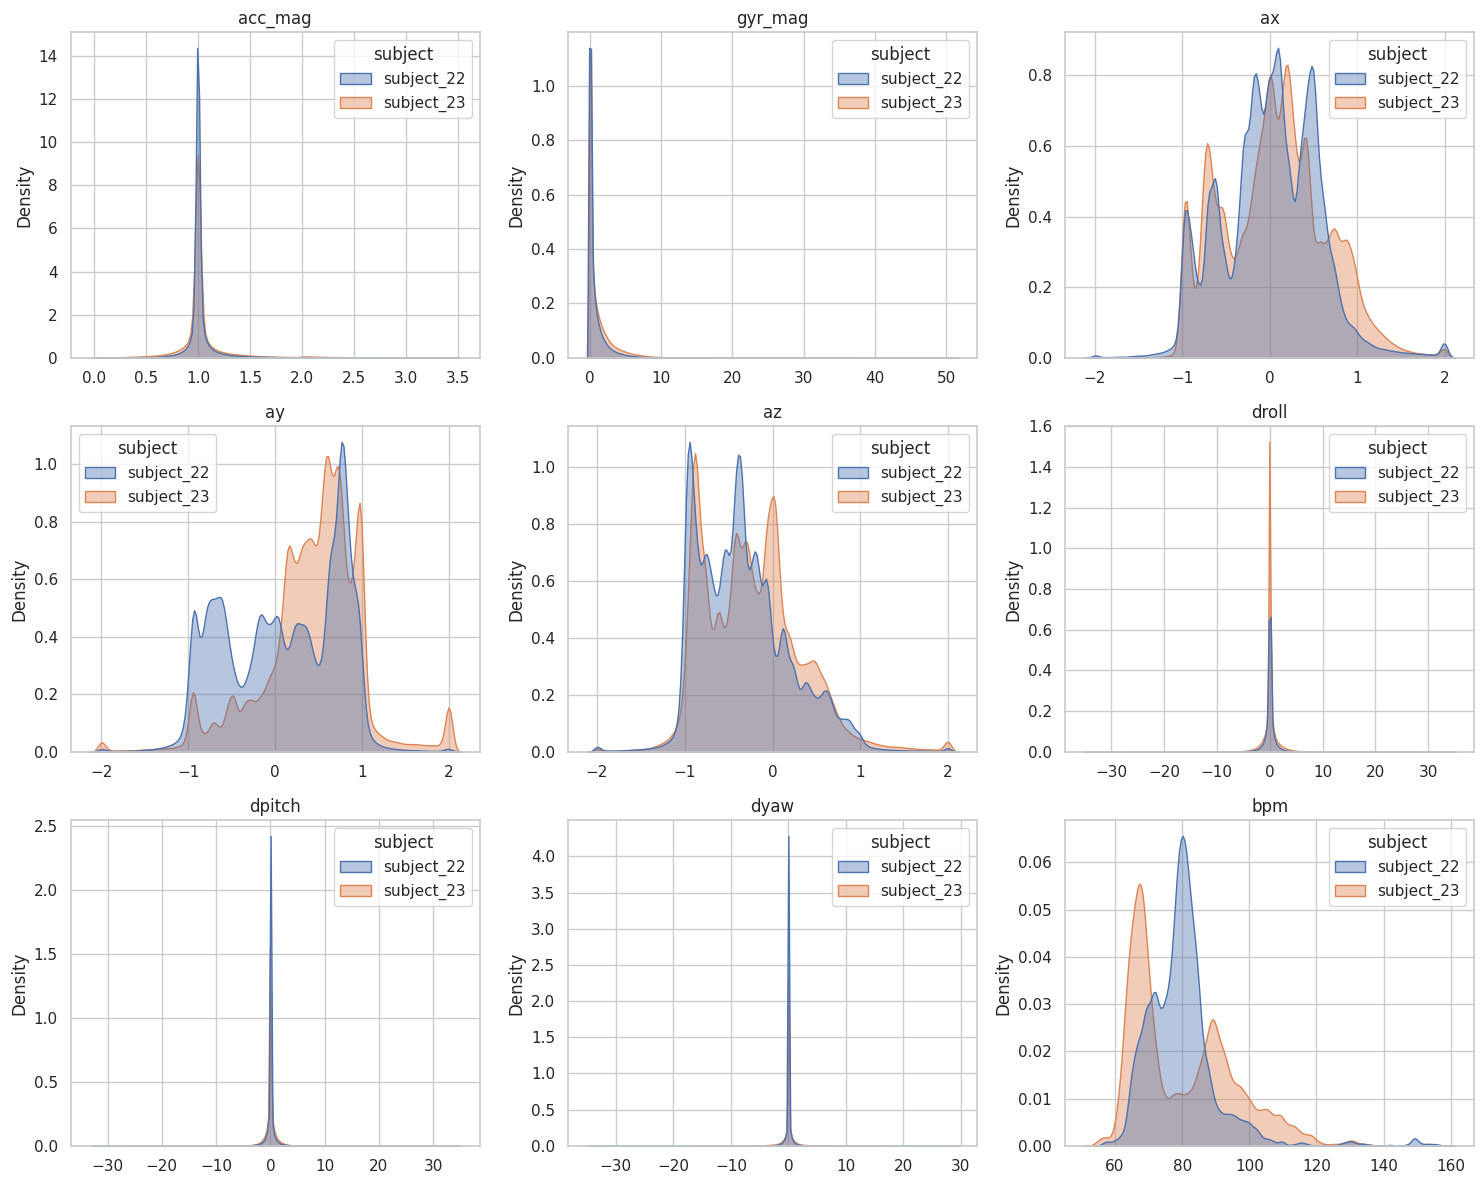

In [58]:
def eda_subject22_vs_23(haelo, n_features=9):
    """
    Compare distributions of key features between subject_22 and subject_23.
    """
    feature_cols = ["acc_mag", "gyr_mag", "ax", "ay", "az", "droll", "dpitch", "dyaw", "bpm"][:n_features]

    df = haelo.copy()
    df = df[df["subject"].isin(["subject_22", "subject_23"])]

    sns.set(style="whitegrid")
    n_cols = 3
    n_rows = int(np.ceil(len(feature_cols) / n_cols))
    plt.figure(figsize=(5 * n_cols, 4 * n_rows))

    for i, col in enumerate(feature_cols, start=1):
        plt.subplot(n_rows, n_cols, i)
        sns.kdeplot(
            data=df,
            x=col,
            hue="subject",
            common_norm=False,
            fill=True,
            alpha=0.4,
        )
        plt.title(col)
        plt.xlabel("")
    plt.tight_layout()
    plt.show()

eda_subject22_vs_23(haelo)


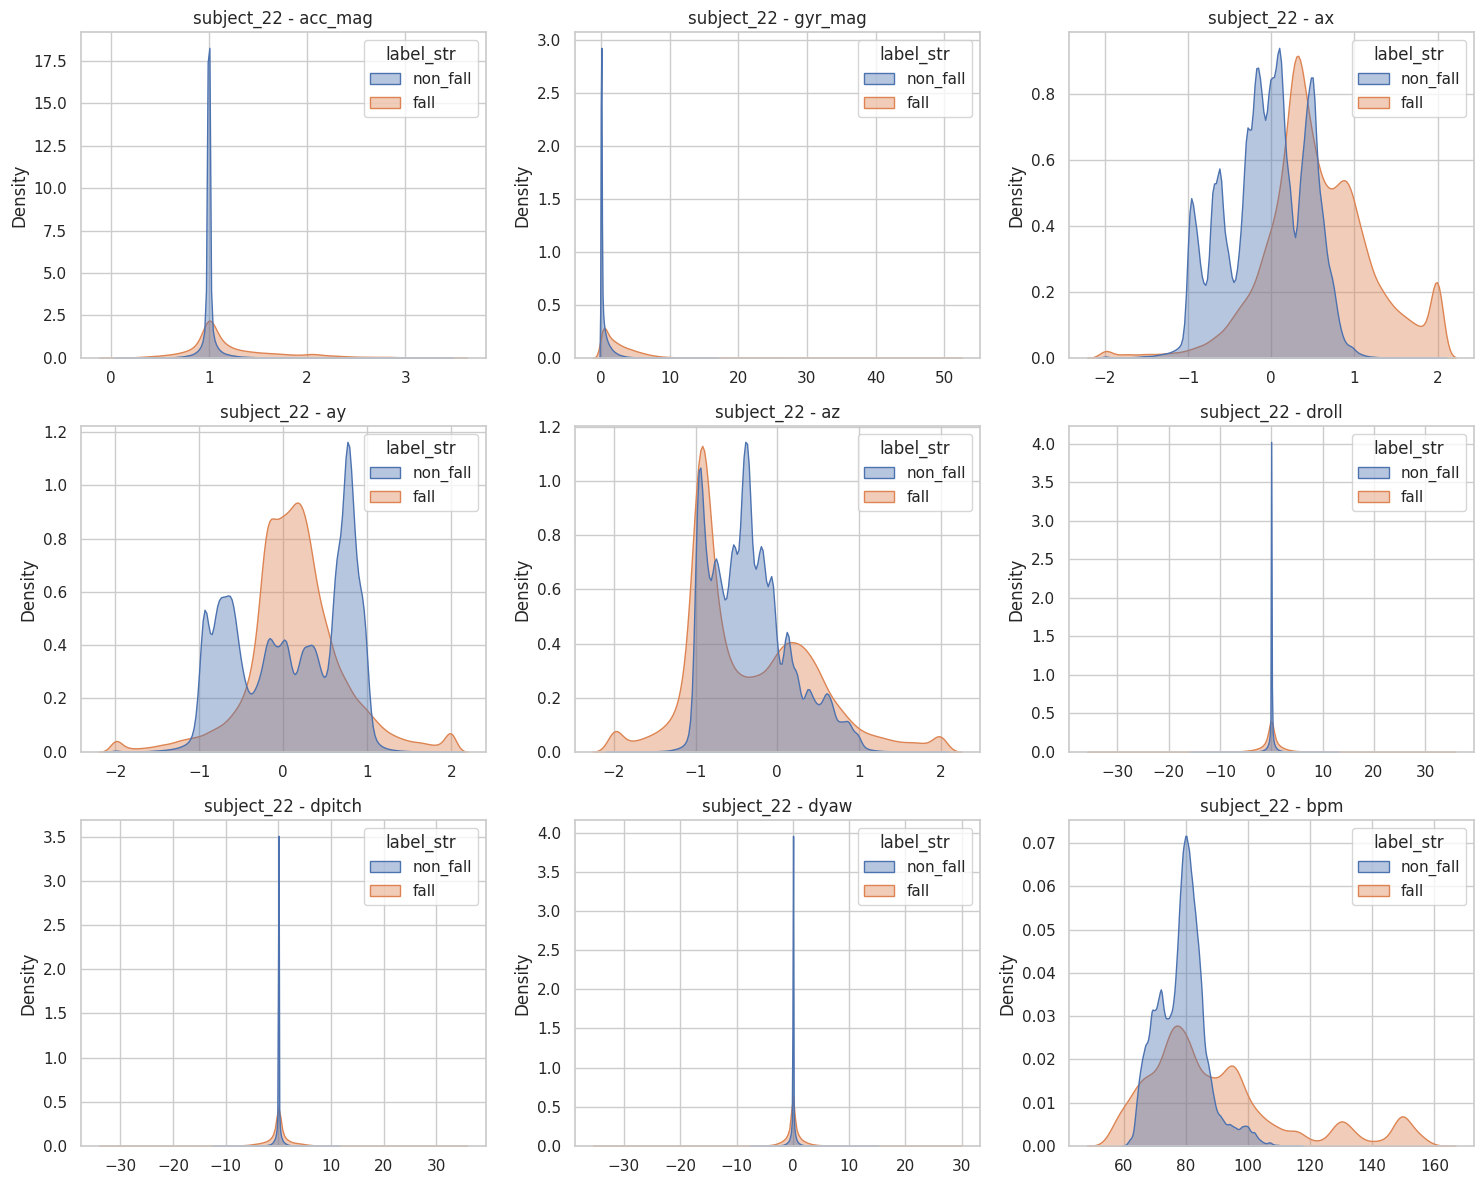

In [59]:
def eda_nonfall_vs_fall_by_subject(haelo, subject_name="subject_22", n_features=9):
    """
    For a given subject, compare non-fall vs fall distributions.
    """
    feature_cols = ["acc_mag", "gyr_mag", "ax", "ay", "az", "droll", "dpitch", "dyaw", "bpm"][:n_features]

    df = haelo[haelo["subject"] == subject_name].copy()
    df["label_str"] = df["label"].map({0: "non_fall", 1: "fall"})

    sns.set(style="whitegrid")
    n_cols = 3
    n_rows = int(np.ceil(len(feature_cols) / n_cols))
    plt.figure(figsize=(5 * n_cols, 4 * n_rows))

    for i, col in enumerate(feature_cols, start=1):
        plt.subplot(n_rows, n_cols, i)
        sns.kdeplot(
            data=df,
            x=col,
            hue="label_str",
            common_norm=False,
            fill=True,
            alpha=0.4,
        )
        plt.title(f"{subject_name} - {col}")
        plt.xlabel("")
    plt.tight_layout()
    plt.show()

eda_nonfall_vs_fall_by_subject(haelo, subject_name="subject_22")

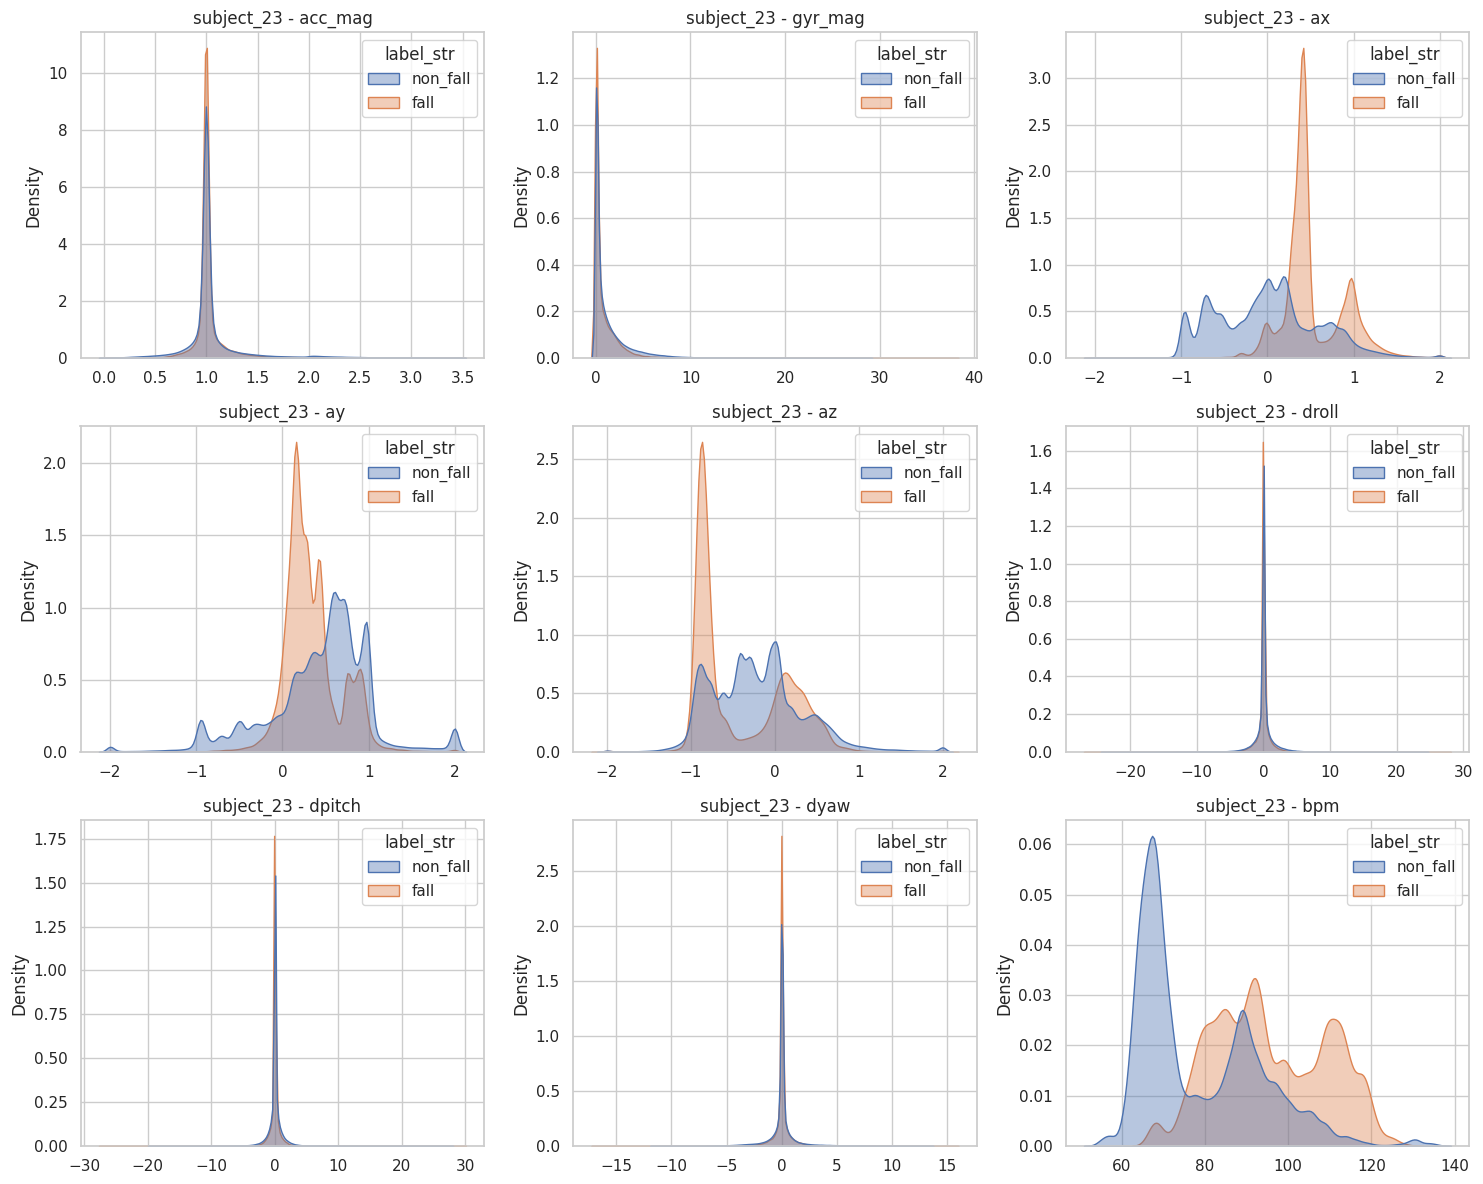

In [60]:
eda_nonfall_vs_fall_by_subject(haelo, subject_name="subject_23")

In [61]:
def eda_subject22_vs_23(haelo, n_features=9):
    """
    Compare distributions of key features between subject_22 and subject_23
    over the whole Haelo dataset.
    """
    feature_cols = ["acc_mag", "gyr_mag", "ax", "ay", "az", "droll", "dpitch", "dyaw", "bpm"][:n_features]

    df = haelo.copy()
    df = df[df["subject"].isin(["subject_22", "subject_23"])]

    sns.set(style="whitegrid")
    n_cols = 3
    n_rows = int(np.ceil(len(feature_cols) / n_cols))
    plt.figure(figsize=(5 * n_cols, 4 * n_rows))

    for i, col in enumerate(feature_cols, start=1):
        plt.subplot(n_rows, n_cols, i)
        sns.kdeplot(
            data=df,
            x=col,
            hue="subject",
            common_norm=False,
            fill=True,
            alpha=0.4,
        )
        plt.title(f"{col} (22 vs 23)")
        plt.xlabel("")
    plt.tight_layout()
    plt.show()


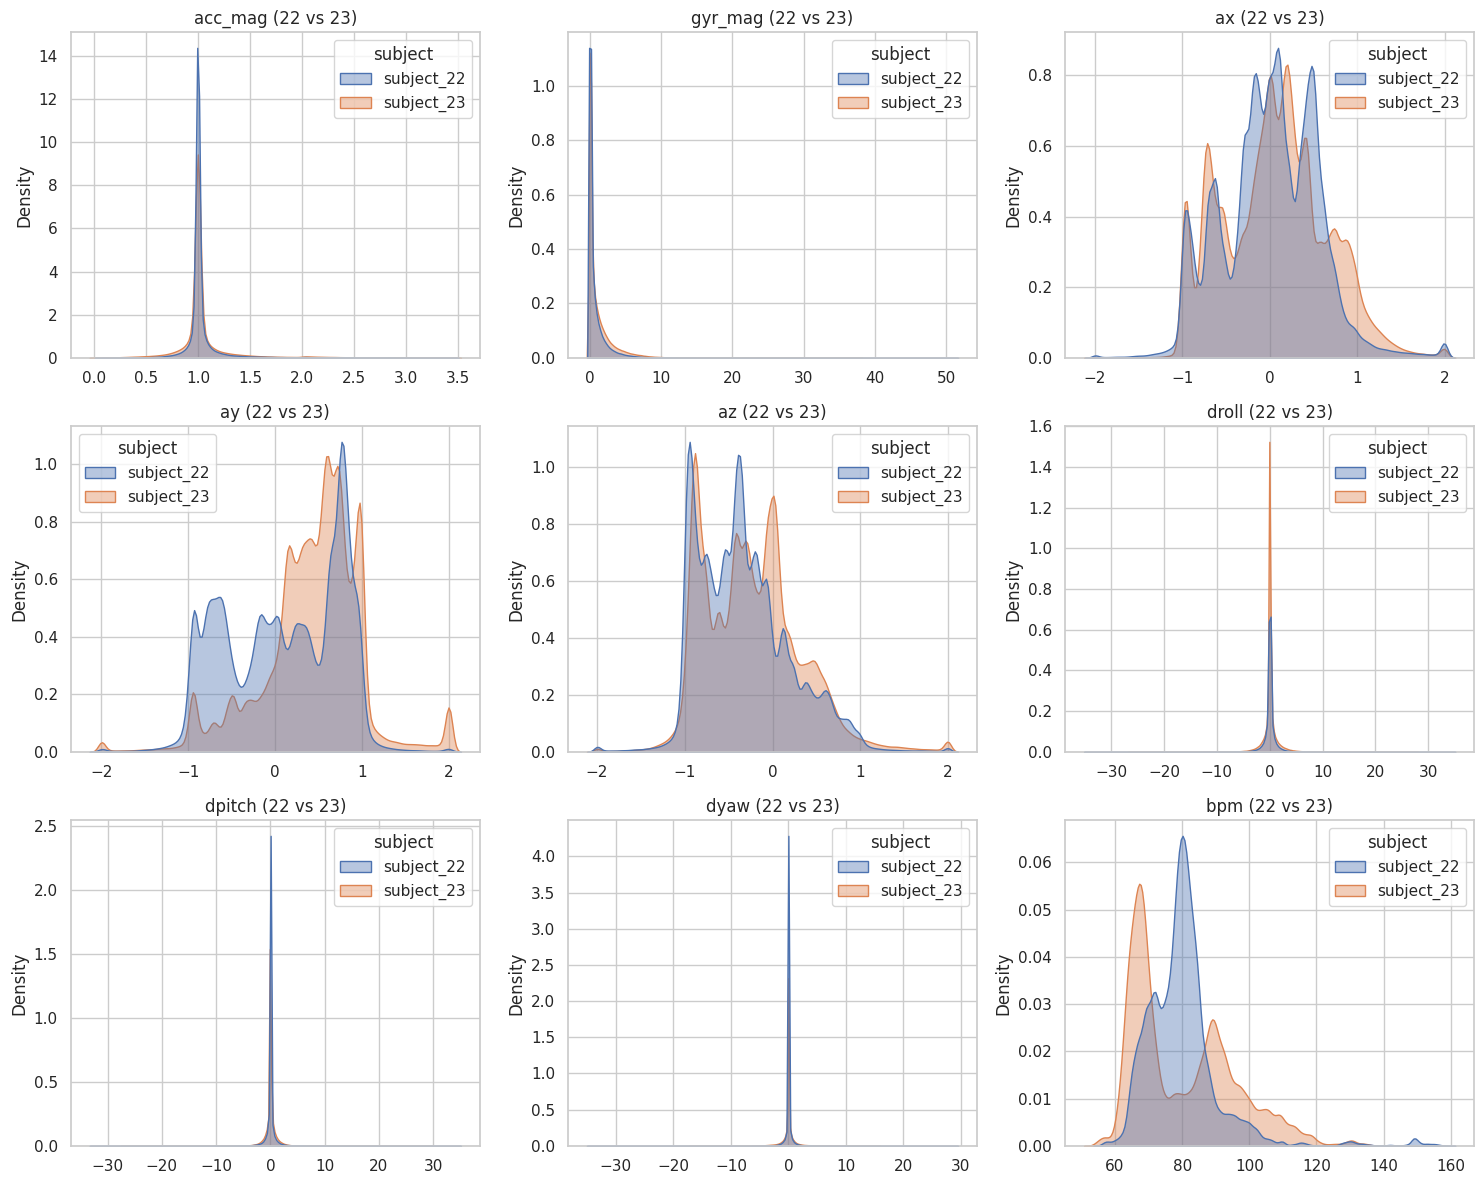

In [62]:
eda_subject22_vs_23(haelo)

**Standardising before feature extraction for Haelo**

In [63]:
mu_df = pd.read_csv("hifd_feature_mean.csv", index_col=0)
sigma_df = pd.read_csv("hifd_feature_std.csv", index_col=0)
mu = mu_df.iloc[:, 0]
sigma = sigma_df.iloc[:, 0]

feat_cols = [
    "ax", "ay", "az",
    "droll", "dpitch", "dyaw",
    "bpm",
    "acc_mag", "gyr_mag",
]

X_hifd = hifd[feat_cols].copy()
X_hifd_z = (X_hifd - mu[feat_cols]) / sigma[feat_cols]

hifd_windows_std = pd.concat(
    [
        hifd[["subject", "label"]].reset_index(drop=True),
        X_hifd_z.reset_index(drop=True),
    ],
    axis=1,
)

X_haelo = haelo_aligned[feat_cols].copy()
X_haelo_z = (X_haelo - mu[feat_cols]) / sigma[feat_cols]

haelo_windows_std = pd.concat(
    [
        haelo_aligned[["subject", "label", "timestamp_ms"]].reset_index(drop=True),
        X_haelo_z.reset_index(drop=True),
    ],
    axis=1,
)

haelo_windows_std

,subject,label,timestamp_ms,ax,ay,az,droll,dpitch,dyaw,bpm,acc_mag,gyr_mag
0,Haelo22_dev,0,1.767490e+12,1.678252,1.774054,-1.099556,-0.008976,-0.004902,-0.012124,-1.160696,1.195409,-0.908851
1,Haelo22_dev,0,1.767490e+12,1.682445,1.768834,-1.104468,-0.008806,-0.004864,-0.012011,-1.160696,1.194944,-0.908825
2,Haelo22_dev,0,1.767490e+12,1.694477,1.773039,-1.095345,-0.008794,-0.004844,-0.011973,-1.160696,1.198838,-0.908791
3,Haelo22_dev,0,1.767490e+12,1.697029,1.756798,-1.107801,-0.008891,-0.004883,-0.012124,-1.160696,1.193407,-0.908907
4,Haelo22_dev,0,1.767490e+12,1.693201,1.747953,-1.109030,-0.008903,-0.004940,-0.012350,-1.160696,1.187369,-0.908864
...,...,...,...,...,...,...,...,...,...,...,...,...
1139995,Haelo23,1,1.767570e+12,1.033786,2.168475,-0.767790,-0.020622,-0.012902,-0.004017,-0.315367,1.219268,-0.895659
1139996,Haelo23,1,1.767570e+12,0.431617,2.067115,-0.573748,-0.009170,-0.033247,-0.008524,-0.315367,1.039257,-0.892785
1139997,Haelo23,1,1.767570e+12,0.393697,2.145419,-0.581117,-0.000096,-0.028385,-0.006673,-0.315367,1.096841,-0.893009
1139998,Haelo23,1,1.767570e+12,0.552124,2.205017,-0.576731,0.016525,-0.029610,-0.003489,-0.315367,1.151266,-0.881590


In [64]:
haelo_windows = extract_window_features_6s_90pct(haelo_windows_std, fs=50)
haelo_windows.to_csv("haelo_windows.csv")
haelo_windows

,subject,label,win_id,acc_energy,acc_max,acc_min,gyr_energy,gyr_max,gyr_min,bpm_mean,...,dyaw_max,dyaw_iqr,dyaw_kurtosis,dyaw_skew,acc_mag_iqr,acc_mag_zcr,acc_mag_slope,acc_mag_area,gyr_mag_iqr,gyr_mag_area
0,Haelo22_dev,0,Haelo22_dev_win_0,420.811319,1.215908,1.152165,247.665149,-0.905924,-0.908989,-1.357714,...,-0.010613,0.000264,4.926939,2.002984,0.013646,0.000000,-0.109967,355.295254,0.000284,272.579383
1,Haelo22_dev,0,Haelo22_dev_win_1,420.721848,1.237734,1.090449,247.538617,-0.901475,-0.908981,-1.216488,...,-0.008448,0.000293,12.056767,-1.480650,0.015292,0.000000,0.098039,355.242920,0.000248,272.509531
2,Haelo22_dev,0,Haelo22_dev_win_2,432.248750,1.698760,0.915224,243.789444,-0.877307,-0.908889,-1.250864,...,-0.002381,0.004346,3.667781,-1.878017,0.054106,0.000000,-0.009244,359.360859,0.007780,270.429295
3,Haelo22_dev,0,Haelo22_dev_win_3,436.517183,1.911149,1.038667,244.269442,-0.864943,-0.908963,-1.194509,...,0.016866,0.004415,4.513606,1.519366,0.079197,0.000000,-0.061687,360.561800,0.009431,270.696292
4,Haelo22_dev,0,Haelo22_dev_win_4,424.219480,1.961406,0.953707,246.546660,-0.886540,-0.908985,-1.196312,...,0.001672,0.000406,6.130800,2.338138,0.018835,0.000000,0.019844,356.135926,0.000567,271.959072
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3992,Haelo23,0,Haelo23_win_3992,441.983828,1.418336,1.059664,247.267980,-0.890212,-0.908989,-1.023865,...,-0.010425,0.000151,11.233123,-2.642028,0.015879,0.000000,0.035092,364.014345,0.000760,272.359780
3993,Haelo23,0,Haelo23_win_3993,442.142731,1.399908,1.077374,247.141731,-0.899154,-0.908942,-0.986107,...,-0.009065,0.000352,5.850373,1.484313,0.025801,0.000000,0.024625,364.103488,0.001079,272.290563
3994,Haelo23,0,Haelo23_win_3994,471.128099,3.621574,0.295266,245.848526,-0.872195,-0.908961,-1.033107,...,0.004668,0.000617,10.992405,-2.345091,0.035836,0.000000,-0.059633,369.453346,0.002108,271.569636
3995,Haelo23,0,Haelo23_win_3995,438.902237,1.270696,1.154313,247.708948,-0.906521,-0.908966,-0.961874,...,-0.011646,0.000201,2.117167,-0.637554,0.016823,0.000000,-0.003436,362.838593,0.000215,272.603520


In [65]:
import warnings
warnings.filterwarnings("ignore")
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    f1_score,
    roc_curve,
    roc_auc_score,
)
from sklearn.model_selection import GroupShuffleSplit
from sklearn.model_selection import GroupKFold
import lightgbm as lgb
import xgboost as xgb


TARGET_COL = "label"
RANDOM_STATE = 42

feat_cols = [
    # accel magnitude
    "acc_energy", "acc_max", "acc_min",
    "acc_mag_iqr", "acc_mag_zcr", "acc_mag_slope", "acc_mag_area",

    # gyro magnitude
    "gyr_energy", "gyr_max", "gyr_min",
    "gyr_mag_iqr", "gyr_mag_area",

    # BPM
    "bpm_mean", "bpm_std", "bpm_min", "bpm_max",
    "bpm_iqr", "bpm_kurtosis", "bpm_skew",

    # accel axes
    "ax_mean", "ax_std", "ax_min", "ax_max", "ax_iqr", "ax_kurtosis", "ax_skew",
    "ay_mean", "ay_std", "ay_min", "ay_max", "ay_iqr", "ay_kurtosis", "ay_skew",
    "az_mean", "az_std", "az_min", "az_max", "az_iqr", "az_kurtosis", "az_skew",

    # gyro axes
    "droll_mean", "droll_std", "droll_min", "droll_max",
    "droll_iqr", "droll_kurtosis", "droll_skew",
    "dpitch_mean", "dpitch_std", "dpitch_min", "dpitch_max",
    "dpitch_iqr", "dpitch_kurtosis", "dpitch_skew",
    "dyaw_mean", "dyaw_std", "dyaw_min", "dyaw_max",
    "dyaw_iqr", "dyaw_kurtosis", "dyaw_skew",
]

def tune_threshold(y_val, y_proba_val):
    best_thr, best_f1 = 0.5, -1.0
    for thr in np.linspace(0.1, 0.9, 17):
        preds = (y_proba_val >= thr).astype(int)
        f1 = f1_score(y_val, preds, zero_division=0)
        if f1 > best_f1:
            best_f1, best_thr = f1, thr
    return best_thr, best_f1


**Models - RF, LGBM, XGB, Logistic**

In [66]:
def make_rf():
    return RandomForestClassifier(
        class_weight="balanced",
        random_state=RANDOM_STATE,
        n_jobs=-1,
        n_estimators=300,
        max_depth=None,
    )

def make_lgbm():
    return lgb.LGBMClassifier(
        objective="binary",
        n_estimators=400,
        learning_rate=0.05,
        num_leaves=31,
        subsample=0.8,
        colsample_bytree=0.8,
        random_state=RANDOM_STATE,
        class_weight="balanced",
        n_jobs=-1,
    )

def make_xgb():
    return xgb.XGBClassifier(
        objective="binary:logistic",
        n_estimators=400,
        learning_rate=0.05,
        max_depth=6,
        subsample=0.8,
        colsample_bytree=0.8,
        reg_lambda=1.0,
        random_state=RANDOM_STATE,
        n_jobs=-1,
        scale_pos_weight=1.0,
        eval_metric="logloss",
        tree_method="hist",
    )

def make_logreg():
    return LogisticRegression(
        penalty="l2",
        C=1.0,
        solver="lbfgs",
        max_iter=1000,
        class_weight="balanced",
        n_jobs=-1,
        random_state=RANDOM_STATE,
    )


**LOSO and Feature importance functions**

In [67]:
from sklearn.model_selection import GroupKFold

def subject_level_cv(X, y, Xy, model_name, make_model_fn, compute_importance=True):
    """
    LOSO over subjects (outer).
    Inner split: subject-level GroupKFold so subjects (including Haelo22_dev)
    rotate between inner-train and inner-val across folds.
    """
    print(f"\n\n================ LOSO CV: {model_name} ================")
    subjects = np.sort(Xy["subject"].unique())
    results = []

    feature_names = X.columns.to_list()
    all_importances = []

    N_INNER_FOLDS = 2 #Change as you will

    for test_subj in subjects:
        print("\n" + "="*70)
        print(f"TEST SUBJECT = {test_subj}")
        print("="*70)

        test_mask = (Xy["subject"] == test_subj).values
        train_mask = ~test_mask

        X_train_full = X.iloc[train_mask]
        y_train_full = y[train_mask]
        Xy_train_full = Xy.iloc[train_mask].reset_index(drop=True)

        X_test = X.iloc[test_mask]
        y_test = y[test_mask]
        Xy_test = Xy.iloc[test_mask].reset_index(drop=True)

        if len(np.unique(y_test)) < 2:
            print("Test subject has only one class; skipping metrics.")

        groups_train = Xy_train_full["subject"].values
        inner_cv = GroupKFold(n_splits=min(N_INNER_FOLDS,
                                           len(np.unique(groups_train))))

        best_thr = 0.5
        best_f1_over_inner = -1.0

        # We can either:
        # (a) tune threshold aggregated over all inner folds, or
        # (b) pick the best single fold.
        # Here, we aggregate: fit on each inner-train, tune on inner-val,
        # and keep the best threshold across folds.
        for inner_fold, (inner_train_idx, inner_val_idx) in enumerate(
                inner_cv.split(X_train_full, y_train_full, groups=groups_train),
                start=1,
        ):
            X_tr = X_train_full.iloc[inner_train_idx]
            y_tr = y_train_full[inner_train_idx]
            X_val = X_train_full.iloc[inner_val_idx]
            y_val = y_train_full[inner_val_idx]

            subs_tr_subjects = Xy_train_full.iloc[inner_train_idx]["subject"].unique()
            subs_val_subjects = Xy_train_full.iloc[inner_val_idx]["subject"].unique()

            print(f"\n[Inner fold {inner_fold}]")
            print("  Train windows:", len(X_tr),
                  "Val:", len(X_val))
            print("  Training subjects:", subs_tr_subjects)
            print("  Validation subjects:", subs_val_subjects)

            model_inner = make_model_fn()
            model_inner.fit(X_tr, y_tr)

            y_proba_val = model_inner.predict_proba(X_val)[:, 1]
            thr_fold, f1_fold = tune_threshold(y_val, y_proba_val)
            print(f"  Best thr on this inner fold: {thr_fold:.2f} (F1={f1_fold:.4f})")

            if f1_fold > best_f1_over_inner:
                best_f1_over_inner = f1_fold
                best_thr = thr_fold

        print(f"\nChosen threshold for OUTER test subject {test_subj}: "
              f"{best_thr:.2f} (best inner F1={best_f1_over_inner:.4f})")

        model = make_model_fn()
        model.fit(X_train_full, y_train_full)

        if compute_importance and hasattr(model, "feature_importances_"):
            all_importances.append(model.feature_importances_)

        y_proba_test = model.predict_proba(X_test)[:, 1]
        y_pred_test = (y_proba_test >= best_thr).astype(int)

        print("\n--- TEST RESULTS (raw, tuned threshold) ---")
        report = classification_report(
            y_test, y_pred_test, digits=4, zero_division=0
        )
        print(report)
        print("Confusion matrix:\n", confusion_matrix(y_test, y_pred_test))

        report_dict = classification_report(
            y_test, y_pred_test, output_dict=True, zero_division=0
        )
        results.append({
            "subject": test_subj,
            "n_test": len(y_test),
            "n_fall_test": int((y_test == 1).sum()),
            "precision_fall": report_dict["1"]["precision"],
            "recall_fall": report_dict["1"]["recall"],
            "f1_fall": report_dict["1"]["f1-score"],
        })

    results_df = pd.DataFrame(results)
    print(f"\n================ SUMMARY (LOSO, window-level) [{model_name}] ================")
    print(results_df)
    print("\nMean performance across subjects:")
    print(results_df.mean(numeric_only=True))

    top_feats_df = None
    if compute_importance and all_importances:
        importances_arr = np.vstack(all_importances)
        mean_importances = importances_arr.mean(axis=0)
        idx = np.argsort(mean_importances)[::-1][:50]

        print(f"\n================ TOP 50 FEATURES (mean over LOSO folds) [{model_name}] ================")
        for rank, i in enumerate(idx, start=1):
            print(f"{rank:2d}. {feature_names[i]:30s} {mean_importances[i]:.6f}")

        top_feats_df = pd.DataFrame({
            "feature": [feature_names[i] for i in idx],
            "importance_mean": [mean_importances[i] for i in idx],
        })

    return results_df, top_feats_df


**Data loading and subject_22 split**

In [68]:
def load_and_split_data():
    """
    hifd_windows: has 'subject' like HIFD_01, HIFD_02, ...
    haelo_windows: has 'subject' with values Haelo22_dev, Haelo22_ext, Haelo23.
    """
    hifd_windows = pd.read_csv("hifd_windows.csv")
    haelo_windows = pd.read_csv("haelo_windows.csv")

    for name, df in [("hifd_windows", hifd_windows), ("haelo_windows", haelo_windows)]:
        missing = set(["subject", "label", "win_id"]) - set(df.columns)
        if missing:
            raise ValueError(f"{name} missing required columns: {missing}")
        missing_feats = set(feat_cols) - set(df.columns)
        if missing_feats:
            raise ValueError(f"{name} missing feature columns: {missing_feats}")

    haelo22_dev = haelo_windows[haelo_windows["subject"] == "Haelo22_dev"].copy()
    haelo22_ext = haelo_windows[haelo_windows["subject"] == "Haelo22_ext"].copy()
    haelo23     = haelo_windows[haelo_windows["subject"] == "Haelo23"].copy()

    print("Haelo22_dev label counts:",
          np.bincount(haelo22_dev["label"].astype(int).values) if len(haelo22_dev) > 0 else "[]")
    print("Haelo22_ext label counts:",
          np.bincount(haelo22_ext["label"].astype(int).values) if len(haelo22_ext) > 0 else "[]")
    print("Haelo23 label counts:",
          np.bincount(haelo23["label"].astype(int).values) if len(haelo23) > 0 else "[]")

    hifd_df = hifd_windows.copy()
    df_loso = pd.concat([hifd_df, haelo22_dev], ignore_index=True)

    X = df_loso[feat_cols].copy()
    y = df_loso["label"].astype(int).values

    meta_cols = ["subject", "win_id"]
    if "file" in df_loso.columns:
        meta_cols.append("file")
    Xy = df_loso[meta_cols + ["label"]].copy()
    if "file" not in Xy.columns:
        Xy["file"] = Xy["subject"].astype(str) + "_dummy"

    if len(haelo22_ext) > 0:
        X_ext22 = haelo22_ext[feat_cols].values
        y_ext22 = haelo22_ext["label"].astype(int).values
    else:
        X_ext22, y_ext22 = None, None

    if len(haelo23) > 0:
        X_ext23 = haelo23[feat_cols].values
        y_ext23 = haelo23["label"].astype(int).values
    else:
        X_ext23, y_ext23 = None, None

    print("\n--- WINDOW VERIFICATION (LOSO dataset: HIFD + Haelo22_dev) ---")
    unique, counts = np.unique(y, return_counts=True)
    print("Counts:", dict(zip(unique, counts)))
    print("Total windows:", len(Xy))

    return X, y, Xy, X_ext22, y_ext22, X_ext23, y_ext23


**Model evaluation**

In [69]:
def external_eval_with_roc(model_name, make_model_fn, X, y, Xy,
                           X_ext22, y_ext22, X_ext23, y_ext23):
    print(f"\n================ FINAL {model_name} ON HIFD + Haelo22_dev ================")

    model = make_model_fn()
    model.fit(X, y)

    gss_global = GroupShuffleSplit(
        n_splits=1, test_size=0.2, random_state=RANDOM_STATE
    )
    groups_global = Xy["subject"].values
    idx_tr, idx_val = next(gss_global.split(X, y, groups=groups_global))
    y_proba_val_global = model.predict_proba(X.iloc[idx_val])[:, 1]
    thr_global, f1_global = tune_threshold(y[idx_val], y_proba_val_global)
    print(f"Global tuned threshold on HIFD+Haelo22_dev: {thr_global:.2f} (F1={f1_global:.4f})")

    fpr22 = tpr22 = auc22 = None
    if X_ext22 is not None and y_ext22 is not None and len(y_ext22) > 0:
        y_proba_ext22 = model.predict_proba(X_ext22)[:, 1]

        print("\n--- {0} on Haelo22_ext (thr={1:.2f}) ---".format(model_name, thr_global))
        y_pred_ext22 = (y_proba_ext22 >= thr_global).astype(int)
        print(classification_report(y_ext22, y_pred_ext22, digits=4, zero_division=0))
        print("Confusion matrix:\n", confusion_matrix(y_ext22, y_pred_ext22))

        print("\n--- {0} on Haelo22_ext (thr=0.50) ---".format(model_name))
        y_pred_ext22_05 = (y_proba_ext22 >= 0.5).astype(int)
        print(classification_report(y_ext22, y_pred_ext22_05, digits=4, zero_division=0))
        print("Confusion matrix:\n", confusion_matrix(y_ext22, y_pred_ext22_05))

        fpr22, tpr22, _ = roc_curve(y_ext22, y_proba_ext22)
        auc22 = roc_auc_score(y_ext22, y_proba_ext22)
    else:
        print("\nSkipping Haelo22_ext external evaluation (no windows found).")

    fpr23 = tpr23 = auc23 = None
    if X_ext23 is not None and y_ext23 is not None and len(y_ext23) > 0:
        y_proba_ext23 = model.predict_proba(X_ext23)[:, 1]

        print("\n--- {0} on Haelo23 (thr={1:.2f}) ---".format(model_name, thr_global))
        y_pred_ext23 = (y_proba_ext23 >= thr_global).astype(int)
        print(classification_report(y_ext23, y_pred_ext23, digits=4, zero_division=0))
        print("Confusion matrix:\n", confusion_matrix(y_ext23, y_pred_ext23))

        print("\n--- {0} on Haelo23 (thr=0.50) ---".format(model_name))
        y_pred_ext23_05 = (y_proba_ext23 >= 0.5).astype(int)
        print(classification_report(y_ext23, y_pred_ext23_05, digits=4, zero_division=0))
        print("Confusion matrix:\n", confusion_matrix(y_ext23, y_pred_ext23_05))

        fpr23, tpr23, _ = roc_curve(y_ext23, y_proba_ext23)
        auc23 = roc_auc_score(y_ext23, y_proba_ext23)
    else:
        print("\nSkipping Haelo23 external evaluation (no windows found).")

    if (fpr22 is not None) and (fpr23 is not None):
        plt.figure(figsize=(7, 6))
        plt.plot(fpr22, tpr22, label=f"Haelo22_ext (AUC={auc22:.3f})")
        plt.plot(fpr23, tpr23, label=f"Haelo23 (AUC={auc23:.3f})")
        plt.plot([0, 1], [0, 1], "k--")
        plt.xlabel("False Positive Rate")
        plt.ylabel("True Positive Rate")
        plt.title(f"ROC on external subjects ({model_name}, accel+BPM)")
        plt.legend(loc="lower right")
        plt.grid(True)
        plt.tight_layout()
        plt.show()
    else:
        print("\nSkipping ROC plot (at least one external set missing).")


**Run all models for comparisions**

Haelo22_dev label counts: [1431  168]
Haelo22_ext label counts: [357  42]
Haelo23 label counts: [1787  212]

--- WINDOW VERIFICATION (LOSO dataset: HIFD + Haelo22_dev) ---
Counts: {np.int64(0): np.int64(3262), np.int64(1): np.int64(397)}
Total windows: 3659


================ LOSO CV: RandomForest ================

TEST SUBJECT = Haelo22_dev

[Inner fold 1]
  Train windows: 1063 Val: 997
  Training subjects: ['subject_01' 'subject_03' 'subject_04' 'subject_06' 'subject_08'
 'subject_09' 'subject_12' 'subject_15' 'subject_16' 'subject_17'
 'subject_20']
  Validation subjects: ['subject_02' 'subject_05' 'subject_07' 'subject_10' 'subject_11'
 'subject_13' 'subject_14' 'subject_18' 'subject_19' 'subject_21']
  Best thr on this inner fold: 0.40 (F1=0.8263)

[Inner fold 2]
  Train windows: 997 Val: 1063
  Training subjects: ['subject_02' 'subject_05' 'subject_07' 'subject_10' 'subject_11'
 'subject_13' 'subject_14' 'subject_18' 'subject_19' 'subject_21']
  Validation subjects: ['subject_01'

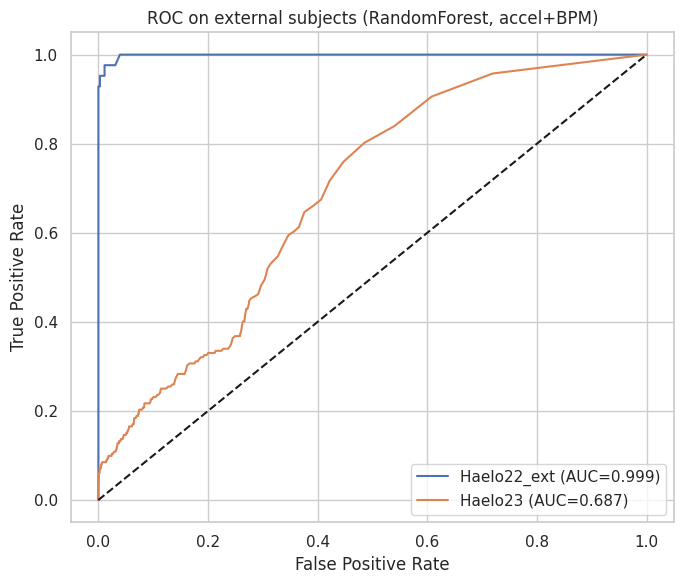

Streaming output truncated to the last 5000 lines.
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with posit

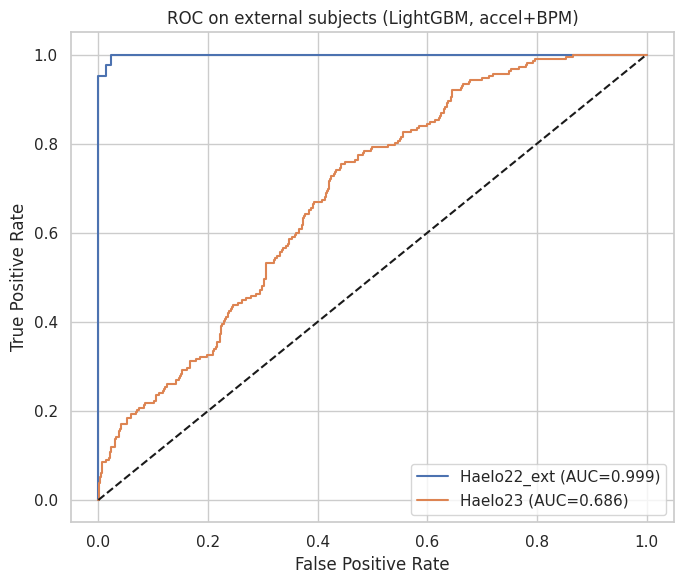



================ LOSO CV: XGBoost ================

TEST SUBJECT = Haelo22_dev

[Inner fold 1]
  Train windows: 1063 Val: 997
  Training subjects: ['subject_01' 'subject_03' 'subject_04' 'subject_06' 'subject_08'
 'subject_09' 'subject_12' 'subject_15' 'subject_16' 'subject_17'
 'subject_20']
  Validation subjects: ['subject_02' 'subject_05' 'subject_07' 'subject_10' 'subject_11'
 'subject_13' 'subject_14' 'subject_18' 'subject_19' 'subject_21']
  Best thr on this inner fold: 0.35 (F1=0.8436)

[Inner fold 2]
  Train windows: 997 Val: 1063
  Training subjects: ['subject_02' 'subject_05' 'subject_07' 'subject_10' 'subject_11'
 'subject_13' 'subject_14' 'subject_18' 'subject_19' 'subject_21']
  Validation subjects: ['subject_01' 'subject_03' 'subject_04' 'subject_06' 'subject_08'
 'subject_09' 'subject_12' 'subject_15' 'subject_16' 'subject_17'
 'subject_20']
  Best thr on this inner fold: 0.70 (F1=0.8797)

Chosen threshold for OUTER test subject Haelo22_dev: 0.70 (best inner F1=0.8797)

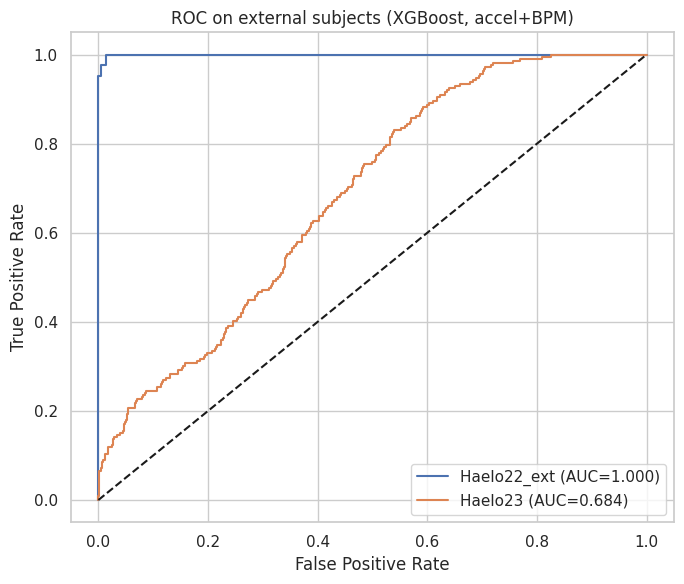

In [70]:
def main_all_models():
    X, y, Xy, X_ext22, y_ext22, X_ext23, y_ext23 = load_and_split_data()

    rf_results, rf_feats = subject_level_cv(X, y, Xy, model_name="RandomForest", make_model_fn=make_rf, compute_importance=True)
    external_eval_with_roc("RandomForest", make_rf, X, y, Xy, X_ext22, y_ext22, X_ext23, y_ext23)

    lgb_results, lgb_feats = subject_level_cv(X, y, Xy, model_name="LightGBM", make_model_fn=make_lgbm, compute_importance=True)
    external_eval_with_roc("LightGBM", make_lgbm, X, y, Xy, X_ext22, y_ext22, X_ext23, y_ext23)

    xgb_results, xgb_feats = subject_level_cv(X, y, Xy, model_name="XGBoost", make_model_fn=make_xgb, compute_importance=True)
    external_eval_with_roc("XGBoost", make_xgb, X, y, Xy, X_ext22, y_ext22, X_ext23, y_ext23)

    #log_results, _ = subject_level_cv(X, y, Xy, model_name="LogReg", make_model_fn=make_logreg, compute_importance=False)
    #external_eval_with_roc("LogReg", make_logreg, X, y, Xy, X_ext22, y_ext22, X_ext23, y_ext23)

if __name__ == "__main__":
    main_all_models()


**RF Model with only Haelo -> 100% but split 80% training and 20% test.**

Train label counts: [2860  337]
Test label counts: [715  85]

Best threshold on VAL (RandomForest): 0.35 (F1=0.9706)

=== RandomForest on Haelo (80/20 temporal split, selected features) ===
              precision    recall  f1-score   support

           0     0.9713    0.5678    0.7167       715
           1     0.1911    0.8588    0.3126        85

    accuracy                         0.5988       800
   macro avg     0.5812    0.7133    0.5147       800
weighted avg     0.8884    0.5988    0.6738       800

Confusion matrix:
 [[406 309]
 [ 12  73]]
AUC on test: 0.8460


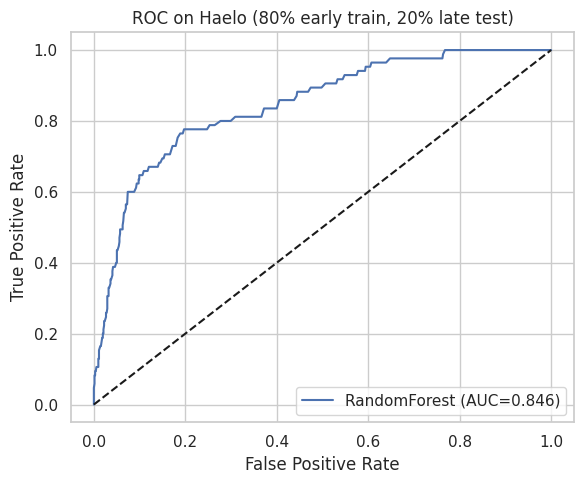

In [71]:

feat_cols = [
    # accel magnitude
    "acc_energy", "acc_max", "acc_min",
    "acc_mag_iqr", "acc_mag_zcr", "acc_mag_slope", "acc_mag_area",

    # gyro magnitude
    "gyr_energy", "gyr_max", "gyr_min",
    "gyr_mag_iqr", "gyr_mag_area",

    # BPM
    "bpm_mean", "bpm_std", "bpm_min", "bpm_max",
    "bpm_iqr", "bpm_kurtosis", "bpm_skew",

    # accel axes
    "ax_mean", "ax_std", "ax_min", "ax_max", "ax_iqr", "ax_kurtosis", "ax_skew",
    "ay_mean", "ay_std", "ay_min", "ay_max", "ay_iqr", "ay_kurtosis", "ay_skew",
    "az_mean", "az_std", "az_min", "az_max", "az_iqr", "az_kurtosis", "az_skew",

    # gyro axes
    "droll_mean", "droll_std", "droll_min", "droll_max",
    "droll_iqr", "droll_kurtosis", "droll_skew",
    "dpitch_mean", "dpitch_std", "dpitch_min", "dpitch_max",
    "dpitch_iqr", "dpitch_kurtosis", "dpitch_skew",
    "dyaw_mean", "dyaw_std", "dyaw_min", "dyaw_max",
    "dyaw_iqr", "dyaw_kurtosis", "dyaw_skew",
]


import numpy as np
import pandas as pd

from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    f1_score,
    roc_curve,
    roc_auc_score,
)
import matplotlib.pyplot as plt

RANDOM_STATE = 42
TARGET_COL = "label"

def tune_threshold(y_val, y_proba_val):
    best_thr, best_f1 = 0.5, -1.0
    for thr in np.linspace(0.1, 0.9, 17):
        preds = (y_proba_val >= thr).astype(int)
        f1 = f1_score(y_val, preds, zero_division=0)
        if f1 > best_f1:
            best_f1, best_thr = f1, thr
    return best_thr, best_f1

def make_rf():
    return RandomForestClassifier(
        class_weight="balanced",
        random_state=RANDOM_STATE,
        n_jobs=-1,
        n_estimators=300,
        max_depth=None,
    )

def load_haelo_only(feat_cols):
    haelo_windows = pd.read_csv("haelo_windows.csv")

    if "timestamp_ms" in haelo_windows.columns:
        haelo_windows = haelo_windows.sort_values("timestamp_ms").reset_index(drop=True)
    else:
        haelo_windows = haelo_windows.sort_values("win_id").reset_index(drop=True)


    df = haelo_windows.copy()
    rows_train = []
    rows_test = []

    for cls in [0, 1]:
        g = df[df[TARGET_COL] == cls]
        n = len(g)
        n_train = int(0.8 * n)  # early 80%
        g_train = g.iloc[:n_train]
        g_test  = g.iloc[n_train:]
        rows_train.append(g_train)
        rows_test.append(g_test)

    df_train = pd.concat(rows_train, ignore_index=True)
    df_test  = pd.concat(rows_test, ignore_index=True)

    print("Train label counts:", np.bincount(df_train[TARGET_COL].astype(int).values))
    print("Test label counts:", np.bincount(df_test[TARGET_COL].astype(int).values))

    X_train = df_train[feat_cols].copy()
    y_train = df_train[TARGET_COL].astype(int).values

    X_test = df_test[feat_cols].copy()
    y_test = df_test[TARGET_COL].astype(int).values

    return X_train, y_train, X_test, y_test, df_train, df_test

def train_and_eval_haelo_only(feat_cols, model_name="RandomForest"):
    X_train, y_train, X_test, y_test, df_train, df_test = load_haelo_only(feat_cols)

    model = make_rf()
    model.fit(X_train, y_train)

    from sklearn.model_selection import train_test_split
    X_tr, X_val, y_tr, y_val = train_test_split(
        X_train, y_train, test_size=0.2, random_state=RANDOM_STATE, stratify=y_train
    )
    model.fit(X_tr, y_tr)

    y_proba_val = model.predict_proba(X_val)[:, 1]
    thr, f1_val = tune_threshold(y_val, y_proba_val)
    print(f"\nBest threshold on VAL ({model_name}): {thr:.2f} (F1={f1_val:.4f})")

    y_proba_test = model.predict_proba(X_test)[:, 1]
    y_pred_test = (y_proba_test >= thr).astype(int)

    print(f"\n=== {model_name} on Haelo (80/20 temporal split, selected features) ===")
    print(classification_report(y_test, y_pred_test, digits=4, zero_division=0))
    print("Confusion matrix:\n", confusion_matrix(y_test, y_pred_test))

    fpr, tpr, _ = roc_curve(y_test, y_proba_test)
    auc = roc_auc_score(y_test, y_proba_test)
    print(f"AUC on test: {auc:.4f}")

    plt.figure(figsize=(6, 5))
    plt.plot(fpr, tpr, label=f"{model_name} (AUC={auc:.3f})")
    plt.plot([0, 1], [0, 1], "k--")
    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.title("ROC on Haelo (80% early train, 20% late test)")
    plt.legend(loc="lower right")
    plt.grid(True)
    plt.tight_layout()
    plt.show()

    return model, thr, (X_train, y_train, X_test, y_test)

if __name__ == "__main__":
    feat_cols = feat_cols  # or feat_cols_gyr, or feat_cols_bpm
    model, thr, splits = train_and_eval_haelo_only(feat_cols, model_name="RandomForest")


In [72]:
haelo_windows

,subject,label,win_id,acc_energy,acc_max,acc_min,gyr_energy,gyr_max,gyr_min,bpm_mean,...,dyaw_max,dyaw_iqr,dyaw_kurtosis,dyaw_skew,acc_mag_iqr,acc_mag_zcr,acc_mag_slope,acc_mag_area,gyr_mag_iqr,gyr_mag_area
0,Haelo22_dev,0,Haelo22_dev_win_0,420.811319,1.215908,1.152165,247.665149,-0.905924,-0.908989,-1.357714,...,-0.010613,0.000264,4.926939,2.002984,0.013646,0.000000,-0.109967,355.295254,0.000284,272.579383
1,Haelo22_dev,0,Haelo22_dev_win_1,420.721848,1.237734,1.090449,247.538617,-0.901475,-0.908981,-1.216488,...,-0.008448,0.000293,12.056767,-1.480650,0.015292,0.000000,0.098039,355.242920,0.000248,272.509531
2,Haelo22_dev,0,Haelo22_dev_win_2,432.248750,1.698760,0.915224,243.789444,-0.877307,-0.908889,-1.250864,...,-0.002381,0.004346,3.667781,-1.878017,0.054106,0.000000,-0.009244,359.360859,0.007780,270.429295
3,Haelo22_dev,0,Haelo22_dev_win_3,436.517183,1.911149,1.038667,244.269442,-0.864943,-0.908963,-1.194509,...,0.016866,0.004415,4.513606,1.519366,0.079197,0.000000,-0.061687,360.561800,0.009431,270.696292
4,Haelo22_dev,0,Haelo22_dev_win_4,424.219480,1.961406,0.953707,246.546660,-0.886540,-0.908985,-1.196312,...,0.001672,0.000406,6.130800,2.338138,0.018835,0.000000,0.019844,356.135926,0.000567,271.959072
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3992,Haelo23,0,Haelo23_win_3992,441.983828,1.418336,1.059664,247.267980,-0.890212,-0.908989,-1.023865,...,-0.010425,0.000151,11.233123,-2.642028,0.015879,0.000000,0.035092,364.014345,0.000760,272.359780
3993,Haelo23,0,Haelo23_win_3993,442.142731,1.399908,1.077374,247.141731,-0.899154,-0.908942,-0.986107,...,-0.009065,0.000352,5.850373,1.484313,0.025801,0.000000,0.024625,364.103488,0.001079,272.290563
3994,Haelo23,0,Haelo23_win_3994,471.128099,3.621574,0.295266,245.848526,-0.872195,-0.908961,-1.033107,...,0.004668,0.000617,10.992405,-2.345091,0.035836,0.000000,-0.059633,369.453346,0.002108,271.569636
3995,Haelo23,0,Haelo23_win_3995,438.902237,1.270696,1.154313,247.708948,-0.906521,-0.908966,-0.961874,...,-0.011646,0.000201,2.117167,-0.637554,0.016823,0.000000,-0.003436,362.838593,0.000215,272.603520


Haelo22_dev label counts: [1431  168]
Haelo22_ext label counts: [357  42]

Best threshold on VAL (RandomForest, Haelo22_dev): 0.45 (F1=0.9375)

=== RandomForest on Haelo22_ext (train=Haelo22_dev, test=Haelo22_ext) ===
              precision    recall  f1-score   support

           0     0.9944    1.0000    0.9972       357
           1     1.0000    0.9524    0.9756        42

    accuracy                         0.9950       399
   macro avg     0.9972    0.9762    0.9864       399
weighted avg     0.9950    0.9950    0.9949       399

Confusion matrix:
 [[357   0]
 [  2  40]]
AUC on Haelo22_ext: 0.9963


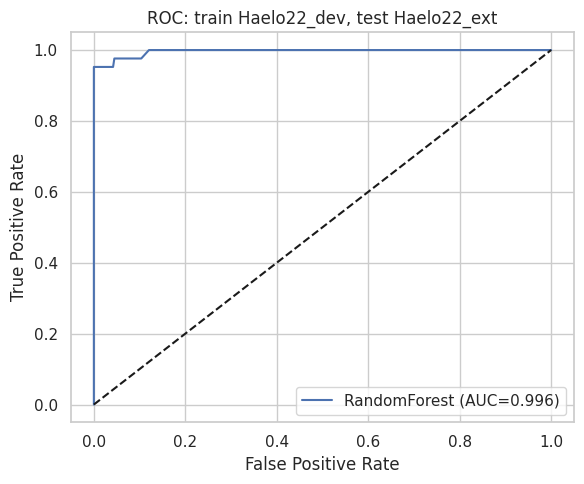

In [73]:
feat_cols = [
    # accel magnitude
    "acc_energy", "acc_max", "acc_min",
    "acc_mag_iqr", "acc_mag_zcr", "acc_mag_slope", "acc_mag_area",

    # gyro magnitude
    "gyr_energy", "gyr_max", "gyr_min",
    "gyr_mag_iqr", "gyr_mag_area",

    # BPM
    "bpm_mean", "bpm_std", "bpm_min", "bpm_max",
    "bpm_iqr", "bpm_kurtosis", "bpm_skew",

    # accel axes
    "ax_mean", "ax_std", "ax_min", "ax_max", "ax_iqr", "ax_kurtosis", "ax_skew",
    "ay_mean", "ay_std", "ay_min", "ay_max", "ay_iqr", "ay_kurtosis", "ay_skew",
    "az_mean", "az_std", "az_min", "az_max", "az_iqr", "az_kurtosis", "az_skew",

    # gyro axes
    "droll_mean", "droll_std", "droll_min", "droll_max",
    "droll_iqr", "droll_kurtosis", "droll_skew",
    "dpitch_mean", "dpitch_std", "dpitch_min", "dpitch_max",
    "dpitch_iqr", "dpitch_kurtosis", "dpitch_skew",
    "dyaw_mean", "dyaw_std", "dyaw_min", "dyaw_max",
    "dyaw_iqr", "dyaw_kurtosis", "dyaw_skew",
]

def tune_threshold(y_val, y_proba_val):
    best_thr, best_f1 = 0.5, -1.0
    for thr in np.linspace(0.1, 0.9, 17):
        preds = (y_proba_val >= thr).astype(int)
        f1 = f1_score(y_val, preds, zero_division=0)
        if f1 > best_f1:
            best_f1, best_thr = f1, thr
    return best_thr, best_f1

def make_rf():
    return RandomForestClassifier(
        class_weight="balanced",
        random_state=RANDOM_STATE,
        n_jobs=-1,
        n_estimators=300,
        max_depth=None,
    )

def load_haelo_dev_ext(feat_cols):
    haelo_windows = pd.read_csv("haelo_windows.csv")

    df_train = haelo_windows[haelo_windows["subject"] == "Haelo22_dev"].copy()
    df_test  = haelo_windows[haelo_windows["subject"] == "Haelo22_ext"].copy()

    print("Haelo22_dev label counts:", np.bincount(df_train[TARGET_COL].astype(int).values))
    print("Haelo22_ext label counts:", np.bincount(df_test[TARGET_COL].astype(int).values))

    X_train = df_train[feat_cols].copy()
    y_train = df_train[TARGET_COL].astype(int).values

    X_test = df_test[feat_cols].copy()
    y_test = df_test[TARGET_COL].astype(int).values

    return X_train, y_train, X_test, y_test, df_train, df_test


def train_and_eval_haelo_dev_ext(feat_cols, model_name="RandomForest"):
    X_train, y_train, X_test, y_test, df_train, df_test = load_haelo_dev_ext(feat_cols)

    model = make_rf()


    from sklearn.model_selection import train_test_split
    X_tr, X_val, y_tr, y_val = train_test_split(
        X_train, y_train, test_size=0.2,
        random_state=RANDOM_STATE, stratify=y_train
    )
    model.fit(X_tr, y_tr)

    y_proba_val = model.predict_proba(X_val)[:, 1]
    thr, f1_val = tune_threshold(y_val, y_proba_val)
    print(f"\nBest threshold on VAL ({model_name}, Haelo22_dev): {thr:.2f} (F1={f1_val:.4f})")


    model.fit(X_train, y_train)

    # Evaluate on Haelo22_ext
    y_proba_test = model.predict_proba(X_test)[:, 1]
    y_pred_test = (y_proba_test >= thr).astype(int)

    print(f"\n=== {model_name} on Haelo22_ext (train=Haelo22_dev, test=Haelo22_ext) ===")
    print(classification_report(y_test, y_pred_test, digits=4, zero_division=0))
    print("Confusion matrix:\n", confusion_matrix(y_test, y_pred_test))

    fpr, tpr, _ = roc_curve(y_test, y_proba_test)
    auc = roc_auc_score(y_test, y_proba_test)
    print(f"AUC on Haelo22_ext: {auc:.4f}")

    plt.figure(figsize=(6, 5))
    plt.plot(fpr, tpr, label=f"{model_name} (AUC={auc:.3f})")
    plt.plot([0, 1], [0, 1], "k--")
    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.title("ROC: train Haelo22_dev, test Haelo22_ext")
    plt.legend(loc="lower right")
    plt.grid(True)
    plt.tight_layout()
    plt.show()

    return model, thr, (X_train, y_train, X_test, y_test)


if __name__ == "__main__":
    model, thr, splits = train_and_eval_haelo_dev_ext(feat_cols, model_name="RandomForest")
